# Customer Segmentation using K-Means Clustering

## 1. Project Overview

Customer segmentation is one of the most common applications of unsupervised Machine Learning branch. Instead of predicting a target variable, clustering algorithms identify groups of customers that share similar characteristics.

From a business perspective, understanding customer segments allows companies to design more personalized marketing strategies, improve customer retention, optimize advertising campaigns, and allocate resources more efficiently.


## 2. Project Objectives
The main objective of this project is to identify meaningful customer segments using the K-Means clustering algorithm and translate the resulting clusters into actionable business insights.

General objectives of this project includes:

* Explore and understand customer demographic and purchasing behavior.
* Prepare the dataset for clustering.
* Determine an appropriate number of customer segments.
* Build a K-Means clustering model.
* Interpret each cluster from a business perspective.
* Provide marketing recommendations based on the identified customer groups.

## 3. Dataset
The dataset used in this project is the Customer Personality Analysis dataset available on Kaggle. It contains demographic information, purchasing behavior, and marketing campaign responses for customers of a retail company.

The objective of the dataset is to identify meaningful customer groups based on their purchasing habits and personal characteristics. By understanding these customer segments, businesses can develop more effective marketing strategies, personalize promotions, and improve customer engagement.

Rather than treating every customer in the same way, customer segmentation allows companies to identify groups with similar behaviors and preferences, making marketing efforts more efficient and data-driven.

The dataset contains 2,240 customer records and 29 variables, which can be grouped into four categories:


| Category      | Description                                                       |
| ------------- | ----------------------------------------------------------------- |
| **People**    | Customer demographic and socioeconomic characteristics.           |
| **Products**  | Amount spent on each product category during the last two years.  |
| **Promotion** | Customer responses to marketing campaigns and promotional offers. |
| **Place**     | Customer purchasing channels and website activity.                |

### 3.1 People Category
| Variable       | Description              |
| -------------- | ------------------------ |
| ID             | Customer identifier      |
| Year_Birth     | Birth year               |
| Education      | Education level          |
| Marital_Status | Marital status           |
| Income         | Annual household income  |
| Kidhome        | Number of children       |
| Teenhome       | Number of teenagers      |
| Dt_Customer    | Enrollment date          |
| Recency        | Days since last purchase |
| Complain       | Complaint indicator      |

### 3.2 Products Category

| Variable         | Description           |
| ---------------- | --------------------- |
| MntWines         | Wine spending         |
| MntFruits        | Fruit spending        |
| MntMeatProducts  | Meat spending         |
| MntFishProducts  | Fish spending         |
| MntSweetProducts | Sweet spending        |
| MntGoldProds     | Gold product spending |

### 3.3 Promotion Category

| Variable          | Description               |
|-------------------| ------------------------- |
| NumDealsPurchases | Purchases using discounts |
| AcceptedCmp1      | Accepted Campaign 1       |
| AcceptedCmp2      | Accepted Campaign 2       |
| AcceptedCmp3      | Accepted Campaign 3       |
| AcceptedCmp4      | Accepted Campaign 4       |
| AcceptedCmp5      | Accepted Campaign 5       |
| Response          | Accepted last campaign    |
| Z_CostContact     | Cost of contact used in campaign data    |
| Z_Revenue         | Revenue value used in campaign data      |

### 3.4 Place Category
| Variable            | Description                  |
| ------------------- | ---------------------------- |
| NumWebPurchases     | Purchases through website    |
| NumCatalogPurchases | Purchases through catalog    |
| NumStorePurchases   | Purchases in physical stores |
| NumWebVisitsMonth   | Website visits last month    |


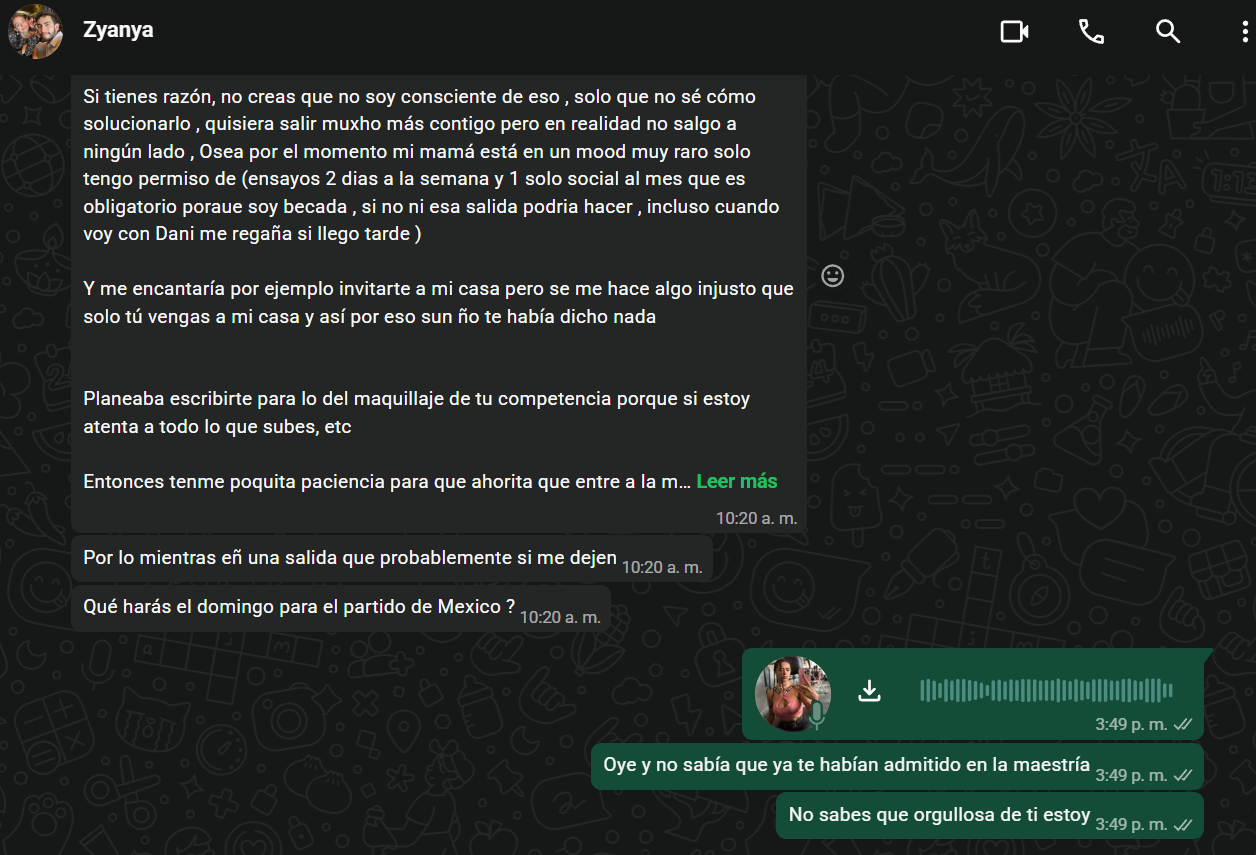

In [121]:
# Import libraries

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler

# Clustering
from sklearn.cluster import KMeans

# Dimensionality reduction
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    pairwise_distances
)

plt.style.use("default")
sns.set_theme(style="whitegrid")

The following table shows the first five observations of the dataset.

In [122]:
# Load dataset
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 4. Exploratory Data Analysis
It is important to understand the structure of the dataset, including the number of observations, variable types, and the presence of missing values.
### 4.1 Dataset Structure

In [124]:
# Data general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [125]:
# Dataset dimensions
df.shape

(2240, 29)

The dataset contains 2,240 observations and 29 variables.


In [126]:
# Data types
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

The dataset contains numerical variables (int64 and float64) together with three variables stored as object: Education, Marital_Status, and Dt_Customer. The latter represents enrollment dates but is currently stored as text rather than as a datetime object.

### 4.2  Numerical Variables Statistics


In [127]:
# Numerical summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### 4.3 Categorical Variables Summary

In [128]:
# Categorical summary
df.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


### 4.4 Missing Values

In [129]:
# Missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [130]:
missing_percentage = (
    df['Income'].isnull().mean() * 100
)

print(f"{missing_percentage:.2f}%")

1.07%


The dataset contains missing values only in the Income variable, with 24 missing observations (1.07% of the dataset). Since the proportion of missing data is very small and Income is expected to play an important role in customer segmentation, these records will be removed during the data preparation stage instead of being imputed.

### 4.5 Correlation Analysis

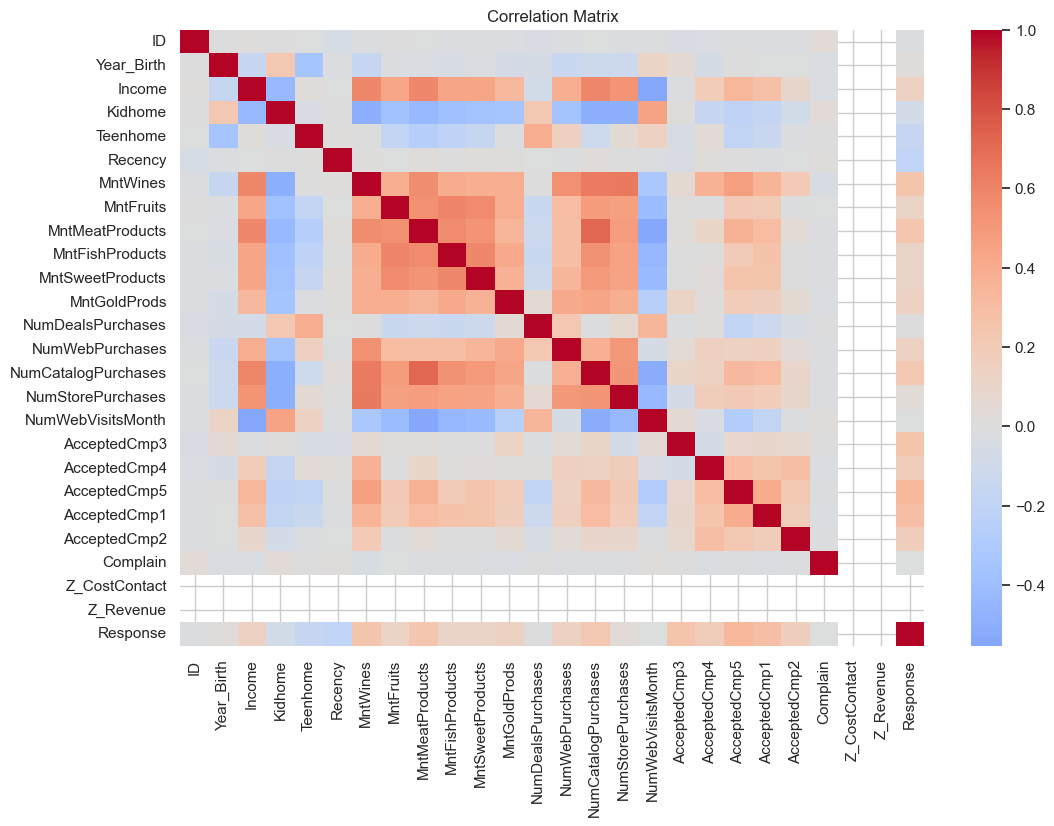

In [131]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

### 4.6 Category Analysis
After analyzing the general structure, distributions, missing values, and relationships between variables, we proceed with a category-based analysis to better understand customer behavior from a business perspective.

The variables are grouped into four categories defined by the dataset: People, Products, Promotion, and Place. This approach allows us to analyze different dimensions of customer behavior before applying the clustering algorithm.
#### 4.6.1 People Analysis
We would like to understand customer's demographics and socioeconomic characteristics in order to answer some questions: Who are our costumers? What is their age, education, income and household composition?



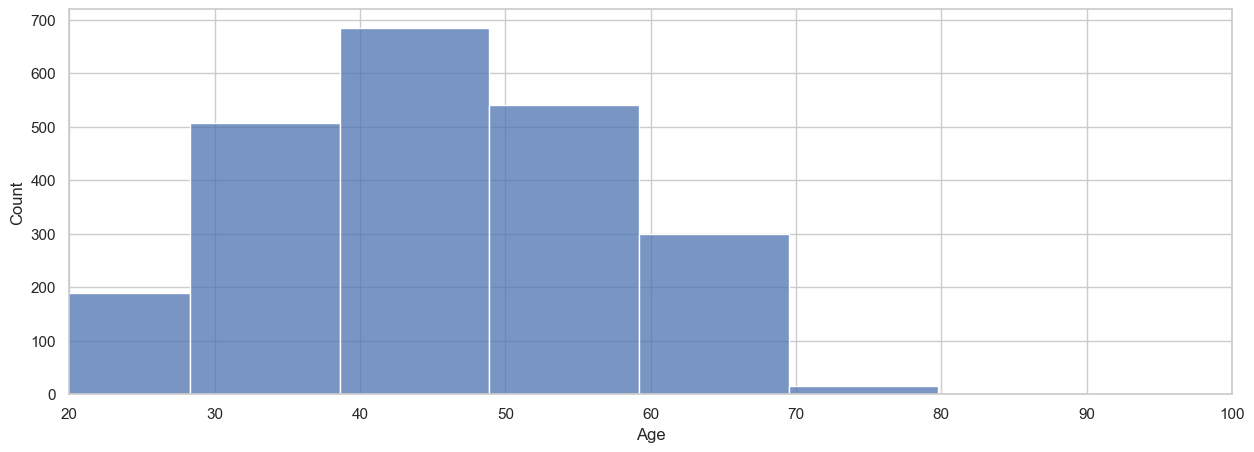

In [132]:
df["Age"] = 2014 - df["Year_Birth"]
# Plot a basic histogram
plt.figure(figsize=(15, 5))
age= sns.histplot(data=df, x= "Age", bins=10)
age.set_xlim(20, 100)
plt.show()

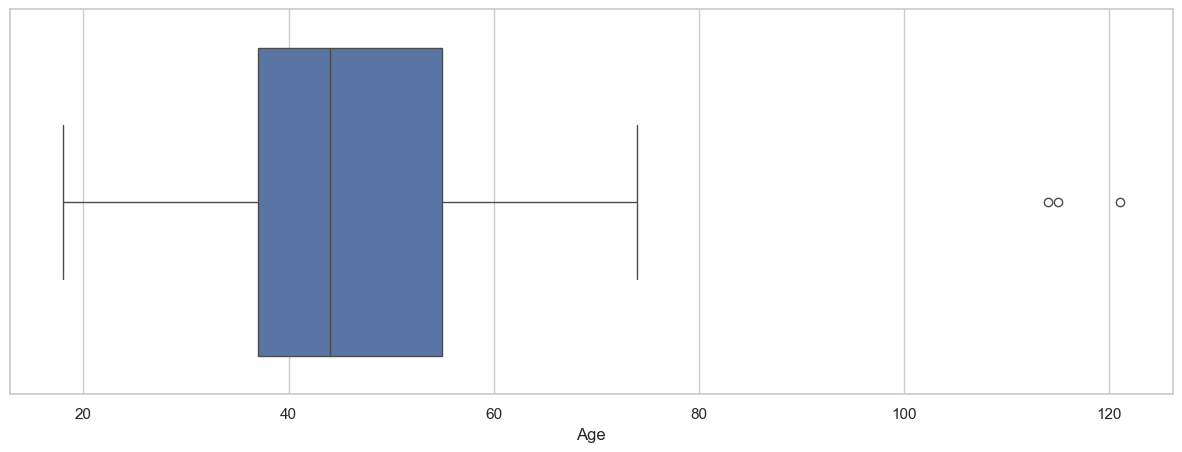

In [133]:
# Plot a basic histogram
plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x= "Age")
plt.show()

<Axes: xlabel='Education', ylabel='count'>

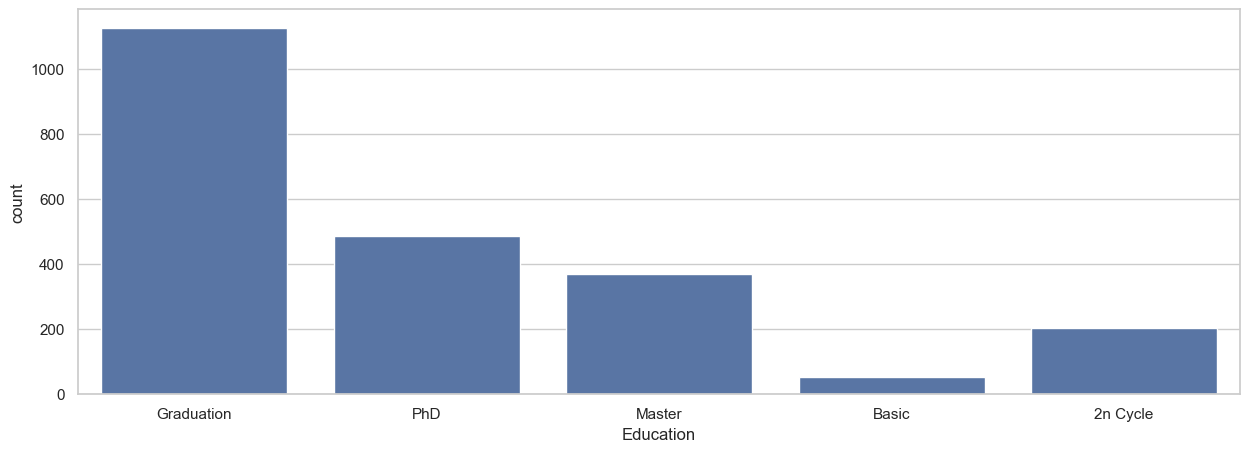

In [134]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Education")

<Axes: xlabel='Marital_Status', ylabel='count'>

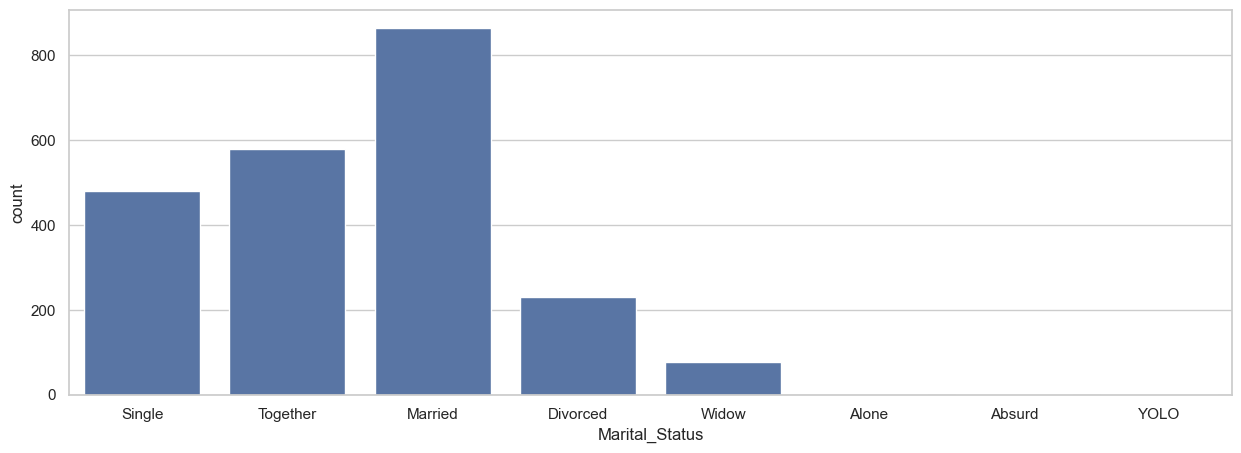

In [135]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Marital_Status")

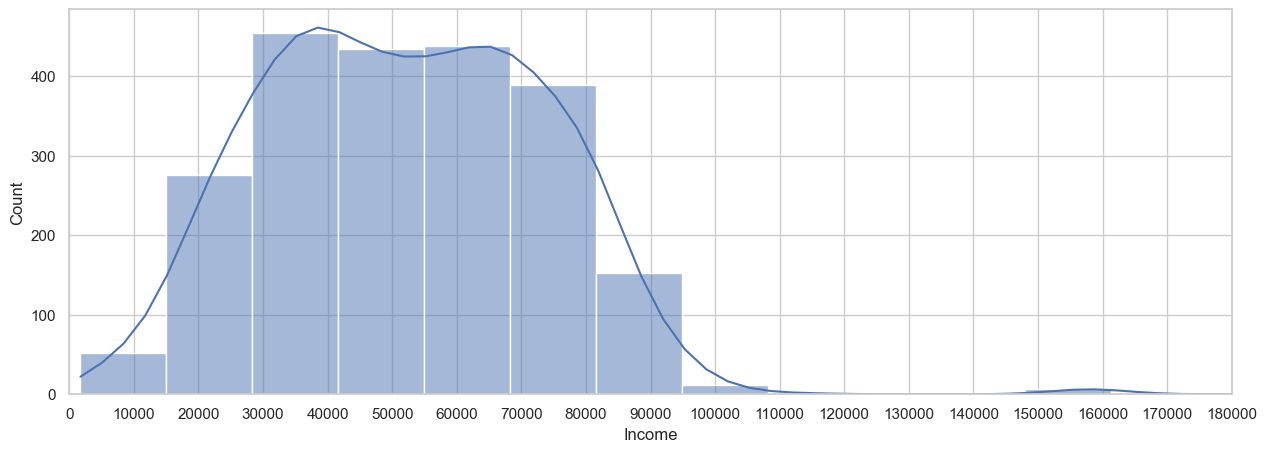

In [136]:
# Plot a basic histogram

import matplotlib.ticker as ticker
plt.figure(figsize=(15, 5))
icm = sns.histplot(data=df, x="Income", bins=50, kde= True)
icm.set_xlim(0, 180000)
icm.xaxis.set_major_locator(ticker.MultipleLocator(10000))

plt.show()

(0.0, 200000.0)

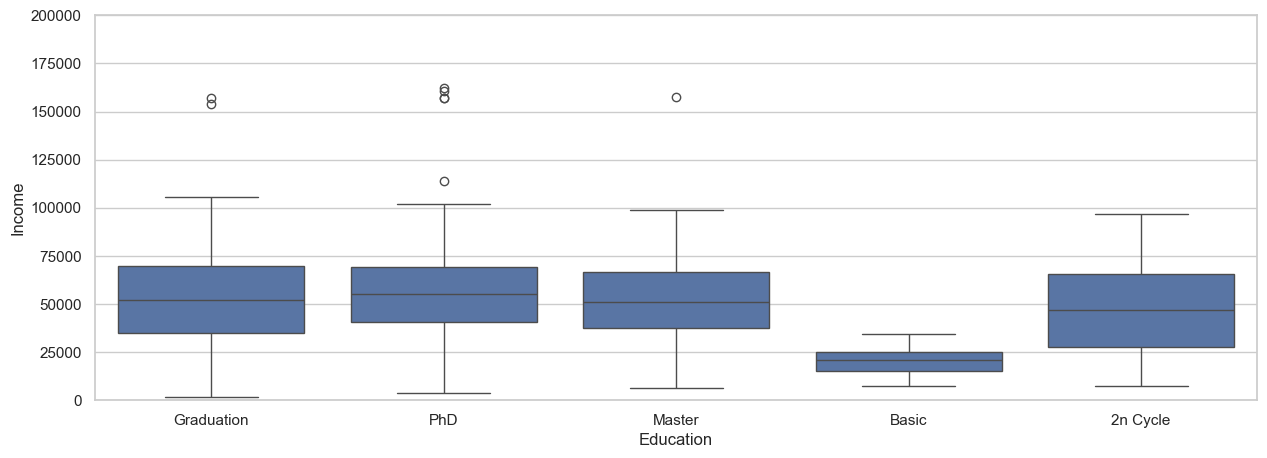

In [137]:
plt.figure(figsize=(15, 5))
eduInc= sns.boxplot(
    data=df,
    x="Education",
    y="Income"
)
eduInc.set_ylim(0, 200000)

##### Main Observations
* Customers are highly concentrated between **$40$ and $50$ years old**, representing the most prominent age group in the dataset.
* The majority of customers have a **Graduation-level** education and are **married**.
* Most customers have an annual **household income** between approximately **$\$30,000$ and $\$70,000$**.
* Customers with a **PhD education level** tend to have slightly **higher incomes** compared with customers from other education groups.

Overall, the customer base is primarily composed of **middle-aged, married customers with a Graduation-level education and moderate household income**. The slightly higher income observed among PhD customers may indicate a relationship between education level and purchasing power, which could be explored further in the segmentation analysis.

#### 4.6.2 Products Analysis
The main puspose is to understand purchasing behavior and product preferences, as well as answering important questions such as: Which products generate the highest spending? Are there any consumption patterns?

<Axes: >

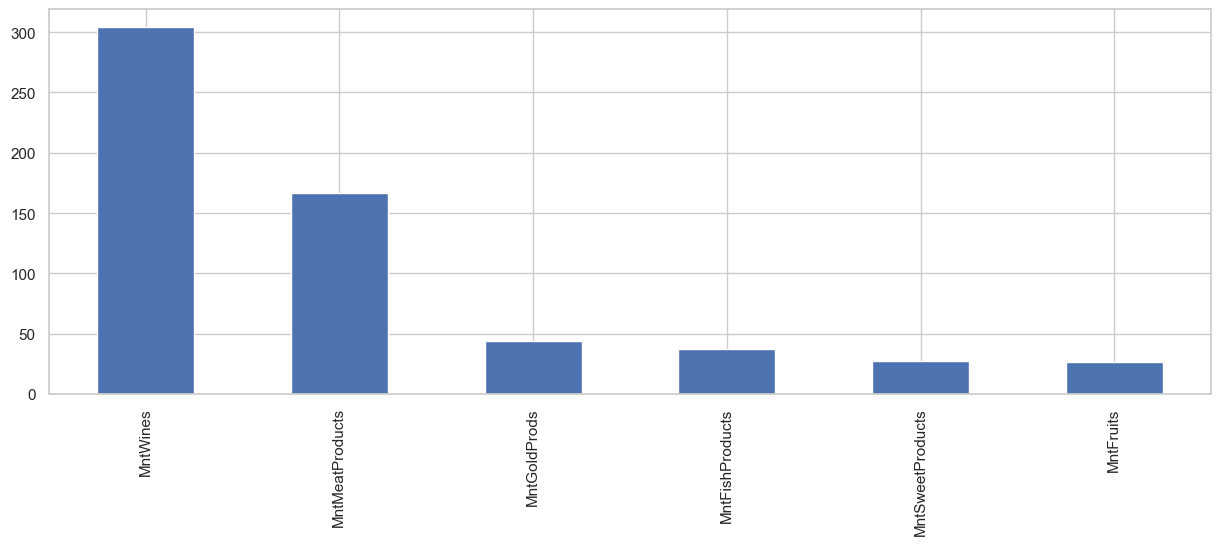

In [138]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]


plt.figure(figsize=(15, 5))
df[product_cols].mean().sort_values(ascending=False).plot.bar()

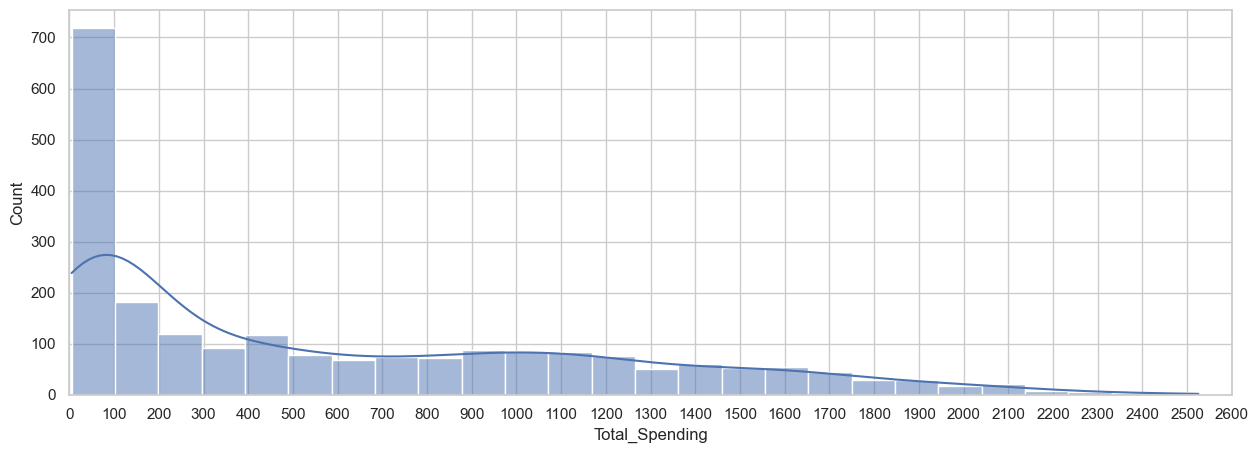

In [139]:
df["Total_Spending"] = df[product_cols].sum(axis=1)

plt.figure(figsize=(15, 5))
total_spend= sns.histplot(data=df, x="Total_Spending", bins= 26, kde= True)
total_spend.set_xlim(0, 2600)
total_spend.xaxis.set_major_locator(ticker.MultipleLocator(100))

##### Main Observations
* Wines are the most purchased product category, showing a clear preference for wine among the customers analyzed.
* Most customers have a relatively low total spending, with the majority spending less than $100 across the analyzed product categories.
* Overall, the customer base appears to be highly concentrated among lower-spending customers, while a smaller group accounts for substantially higher spending.

These findings suggest that wine represents an important product category within the customer base, while most customers exhibit relatively low overall spending. This spending pattern may be useful for identifying distinct customer segments based on purchasing behavior.

#### 4.6.3 Promotion Analysis
Understanding the respose of our clients for the current marketing strategies is important in order to take decisions regards it. We would like to have key information about which campaigns have a better acceptance and if customers are responsive to discounts.

In [140]:
# Calculate the percentage of customers who accepted each campaign

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

acceptance_rate = df[campaign_cols].mean() * 100

acceptance_rate

AcceptedCmp1     6.428571
AcceptedCmp2     1.339286
AcceptedCmp3     7.276786
AcceptedCmp4     7.455357
AcceptedCmp5     7.276786
Response        14.910714
dtype: float64

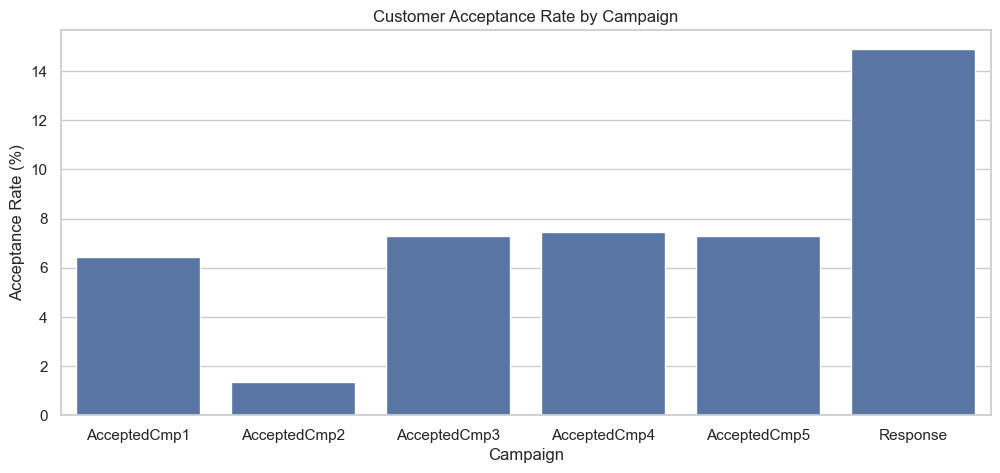

In [141]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=acceptance_rate.index,
    y=acceptance_rate.values
)

plt.xlabel("Campaign")
plt.ylabel("Acceptance Rate (%)")
plt.title("Customer Acceptance Rate by Campaign")


plt.show()

##### Main Observations
The last campaign was the most successful, as it achieved the highest customer acceptance. In contrast, the second campaign performed the worst, showing the lowest level of customer acceptance. Overall, these results suggest that the strategies used in the final campaign were more effective in engaging customers.


#### 4.6.4 Place Analysis
The main purpose for a place analysis is to understand purchasing channels and shopping behavior. Gives us information about the customer´s preferences between buying on stores, websites or catalogs, and how often they interact with each of them.

In [142]:
place_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

place_means = df[place_cols].mean()
place_means

NumWebPurchases        4.084821
NumCatalogPurchases    2.662054
NumStorePurchases      5.790179
dtype: float64

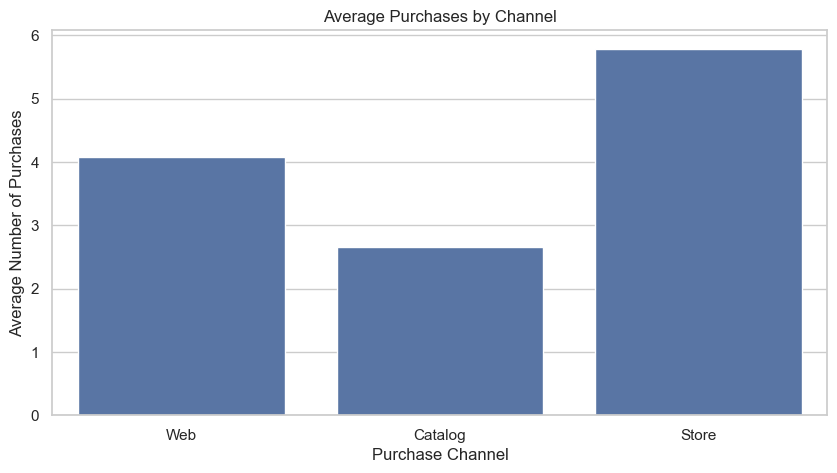

In [143]:
place_labels = [
    "Web",
    "Catalog",
    "Store"
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=place_labels,
    y=place_means.values
)

plt.xlabel("Purchase Channel")
plt.ylabel("Average Number of Purchases")
plt.title("Average Purchases by Channel")

plt.show()

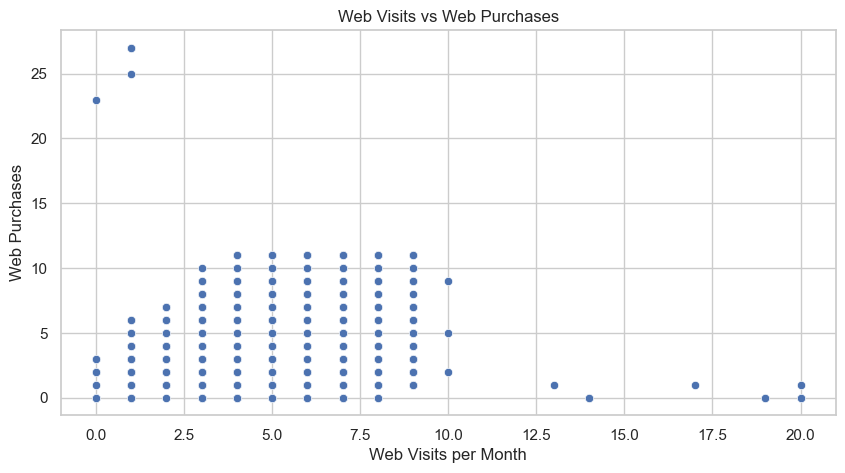

In [144]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="NumWebVisitsMonth",
    y="NumWebPurchases"
)

plt.xlabel("Web Visits per Month")
plt.ylabel("Web Purchases")
plt.title("Web Visits vs Web Purchases")

plt.show()

In [145]:
df["NumWebVisitsMonth"].corr(df["NumWebPurchases"])

np.float64(-0.05584633165982069)

##### Main Observations
* Customers tend to make more purchases through physical stores than through web or catalog channels.

* Web visits and online purchases do not show a clear positive relationship. Most customers are concentrated between 0 and 10 monthly visits, while purchase behavior varies considerably within this range. Some customers generate a relatively high number of online purchases with few visits, whereas others show frequent website visits but very few purchases. This suggests that website engagement alone may not be a strong indicator of online purchasing behavior.

### 4.7 EDA Conclusions

The exploratory data analysis provides an overall understanding of the customers' demographic characteristics, purchasing behavior, promotional responses, and preferred purchasing channels.

The customer base is mainly composed of middle-aged customers with Graduation-level education, married status, and moderate household income. From a purchasing perspective, wine is the most prominent product category, while total spending is highly concentrated among lower-spending customers, with a smaller group accounting for substantially higher spending.

Regarding promotional activity, the latest campaign achieved the highest customer acceptance, whereas the second campaign showed the lowest performance. In terms of purchasing channels, physical stores are the most frequently used channel, while website visits do not show a clear positive relationship with online purchases.

Overall, the EDA suggests substantial variation in customer characteristics, spending behavior, campaign responsiveness, and purchasing channels. These differences provide a meaningful basis for identifying groups of customers with similar characteristics through clustering.

## 5. Data Cleaing and Preprocessing

After the Exploratory Data Analysis we must identify data quality issues on our database:
* Missing Values
* Duplicates
* Invalid values
* Inconsistent categorical values
* Incorrect data types
* Potential outliers
* Variables that need transformation

The purpose of this section is to clean data and preprocess it in order to use it correctly for our next chapter for segmentation.


In [146]:
# Create a copy of the original dataset
df_clean = df.copy()

print(df_clean.shape)

(2240, 31)


### 5.1 Missing Values

In [147]:
df_clean.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Total_Spending          0
dtype: int64

In [148]:
(df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)

Income                 1.071429
Year_Birth             0.000000
ID                     0.000000
Education              0.000000
Marital_Status         0.000000
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
Age                    0.000000
Total_Spending         0.000000
dtype: f

"Income" presents 1.07% of nulls, that represents 24 observations without data for customer´s income. This is a very small percentage of missing values, and dropping this values wouldn´t represent an important distortion on our data. Since is a small proportion, we decide that deleting them is a reazonable procedure to handle this missing values.


In [149]:
df_clean = df_clean.dropna(subset=["Income"])
df_clean.shape

(2216, 31)

### 5.2 Handle Duplicates

In [150]:
df_clean.duplicated().sum()

np.int64(0)

No issues were detected, therefore no transformation was required.

### 5.3 Correct Data Types

In [151]:
print(df_clean.dtypes)


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
Age                      int64
Total_Spending           int64
dtype: object


"Dt_Customers" appears as an **object** variable, which makes no sense considerating that cointains date information. Then we proceed to convert data type to **datetime**

In [153]:
df_clean["Dt_Customer"] = pd.to_datetime(
    df_clean["Dt_Customer"],
    dayfirst=True
)

In [154]:
df_clean["Dt_Customer"]

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2216, dtype: datetime64[ns]

### 5.4 Hangle Invalid and Inconsistent Values


In [155]:
df_clean["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [156]:
df_clean["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

"Education" show no inconsistencies on the values presented, therefore there´s no modification for it.

In [157]:
df_clean["Marital_Status"].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [158]:
df_clean["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [159]:
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace({
    "Alone": "Single",
    "Absurd": "Single",
    "YOLO": "Single"
})
df_clean["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      478
Divorced    232
Widow        76
Name: count, dtype: int64

"Marital Status" on the other hand shows three values that does not correspond to a real marital status: Alone, Absurd and YOLO.
For handling this inconsistencies we inffer that this three invalid categories can consolidated into Single. We choose to correct this observations rather than missing important information about this customers

In [160]:
df_clean[["Year_Birth", "Income", "Kidhome", "Teenhome","Recency", "Complain" ]].describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,0.505415,49.012635,0.009477
std,11.985554,25173.076661,0.536896,0.544181,28.948352,0.096907
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000


We observe extreme outliers for "Year_Birth" and "Income" that need to be analyzed in order to handle them correctly. For "Kidhome", "Teenhome","Recency" and "Complain" we found a reasonable distribution of the data and no modifications are required for them.

In [161]:
df_clean[df_clean["Year_Birth"] < 1920][["ID", "Year_Birth"]]

,ID,Year_Birth
192,7829,1900
239,11004,1893
339,1150,1899


In [162]:
df_clean[df_clean["Year_Birth"] < 1940]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,1,3,11,0,114,65
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,3,11,0,121,22
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,1,0,0,0,3,11,0,115,1853


In [163]:
df_clean.loc[df_clean["Year_Birth"] < 1914, "Year_Birth"] = np.nan
df_clean["Year_Birth"].isnull().sum()

np.int64(3)

In [164]:
df_clean[df_clean["Year_Birth"].isna() ]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
192,7829,NaN,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,1,3,11,0,114,65
239,11004,NaN,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,3,11,0,121,22
339,1150,NaN,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,1,0,0,0,3,11,0,115,1853


Three records contained birth years earlier than 1914, which would imply an age above 100 years, assuming 2014 as the reference year for this dataset. These values were considered invalid and converted to missing values for further treatment during the missing-value handling stage. We chose to convert them to NaN to prevent these invalid values from affecting next calculations. Deleting the records was not considered an appropriate option because information could be lost. Therefore, we decided to keep these observations while treating their age-related information as missing.
These missing values will be addressed later during the missing-value treatment stage.

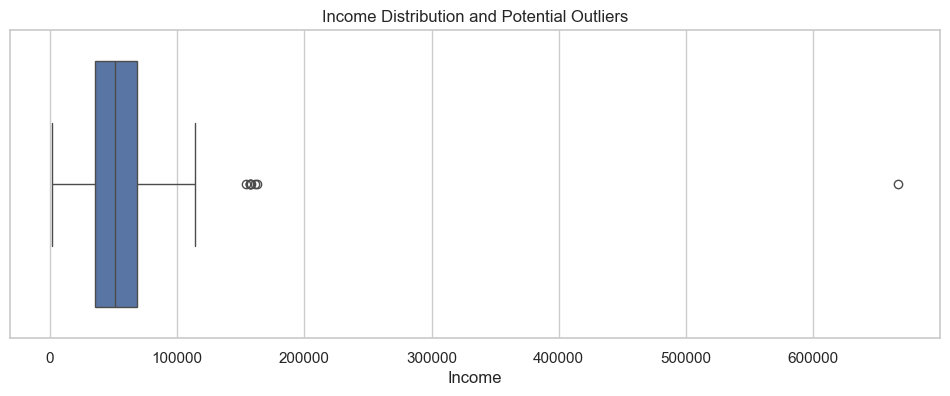

In [165]:
plt.figure(figsize=(12, 4))

sns.boxplot(data=df_clean, x="Income")

plt.title("Income Distribution and Potential Outliers")
plt.xlabel("Income")

plt.show()

In [166]:
df_clean["Income"].sort_values(ascending=False).head(10)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

In [167]:
df_clean[df_clean["Income"] > 600000]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
2233,9432,1977.0,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,0,0,0,0,0,3,11,0,37,62


In [168]:
df_clean.loc[df_clean["Income"]> 600000, "Income"] = np.nan
df_clean["Income"].isnull().sum()

np.int64(1)

One record contained an "Income" value of $\$666,666$, which was identified as an extreme and potentially invalid value. The observation was isolated from the rest of the "Income" distribution, with the next highest value being approximately $\$162,397$. Given the magnitude of the difference and the unusual repeated-digit value, 666,666 was considered an invalid entry and converted to NaN for further treatment during the missing-value handling stage. This decision also helps prevent the value from disproportionately influencing distance-based clustering methods such as K-Means.

In [169]:
df_clean[product_cols].describe()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253
std,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000
50%,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000
75%,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000
max,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000


The descriptive statistics of the **product spending variables** show values within a reasonable range, with all variables having a minimum value of 0 and no apparent negative or excessively extreme values. Although the spending variables show considerable variability, their distributions are consistent with the expected purchasing behavior represented in the dataset. Therefore, no modifications or transformations will be applied to these variables during the data cleaning stage, and their original values will be retained for further analysis and customer segmentation.

In [170]:
df_clean[campaign_cols].describe()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,0.064079,0.013538,0.073556,0.074007,0.073105,0.150271
std,0.244950,0.115588,0.261106,0.261842,0.260367,0.357417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The **promotion variables** also show values consistent with their expected structure and range. The campaign acceptance variables are binary, while the number of deal-based purchases falls within a valid range. No modifications were required.

In [171]:
df_clean[place_cols].describe()


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2216.000000,2216.000000,2216.000000
mean,4.085289,2.671029,5.800993
std,2.740951,2.926734,3.250785
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000
50%,4.000000,2.000000,5.000000
75%,6.000000,4.000000,8.000000
max,27.000000,28.000000,13.000000


The **purchasing-channel variables** present valid values within their expected ranges. No apparent invalid or inconsistent values were identified, so no modifications were required.

Overall, the **Products**, **Promotion**, and **Place** columns presented values within reasonable and expected ranges. No additional invalid values were identified in these groups, so the original values were retained.

##### Missing Values Treatment
Before Feature Engineering, we must handle the missing values that we created.

In [172]:
#Counting nulls on each variable
df_clean.isnull().sum()

ID                     0
Year_Birth             3
Education              0
Marital_Status         0
Income                 1
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Total_Spending         0
dtype: int64

In [173]:
df_clean.loc[df_clean['Year_Birth'].isna()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
192,7829,NaN,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,1,3,11,0,114,65
239,11004,NaN,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,3,11,0,121,22
339,1150,NaN,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,1,0,0,0,3,11,0,115,1853


In [174]:
df_clean.loc[df_clean['Income'].isna()]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
2233,9432,1977.0,Graduation,Together,NaN,1,0,2013-06-02,23,9,...,0,0,0,0,0,3,11,0,37,62


In [175]:
df_clean[['Year_Birth', 'Income']].agg(['mean', 'median', 'min', 'max'])

,Year_Birth,Income
mean,1968.917307,51969.8614
median,1970.000000,51373.0000
min,1940.000000,1730.0000
max,1996.000000,162397.0000


In [176]:
df_clean['Year_Birth'] = df_clean['Year_Birth'].fillna(df_clean['Year_Birth'].median())
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())
df_clean[['Year_Birth', 'Income']].isnull().sum()

Year_Birth    0
Income        0
dtype: int64

In [177]:
print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Dataset shape: (2216, 31)
Missing values: 0
Duplicate rows: 0


During the initial data cleaning process, potential outliers were identified in the **"Year_Birth"** and **"Income"** variables. It was decided not to remove them, considering it would result in a loss of potentially valuable customer information. Instead, they were converted to missing values (NaN) so that the observations could be treated later.
In order to treat them, the distributions of both variables were examined by comparing their mean, median, minimum, and maximum values. Given the very small number of missing values and the presence of influential extreme values, particularly in Income, the **median** was selected as the imputation method because it is more robust to outliers than the mean. The missing values were replaced with the respective variable medians, and the dataset was then checked to confirm that no missing values remained before proceeding to Feature Engineering.

## 6. Feature Engineering
With a cleanned and preprocessed dataset, we can build new helpfull based on the original information. This is helpfull to summary information and have a practical management of data.

### 6.1 From People Category

In [178]:
df_clean["Age"] = 2014 - df_clean["Year_Birth"]
df_clean["Age"].describe()

count    2216.000000
mean       45.081227
std        11.692358
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64

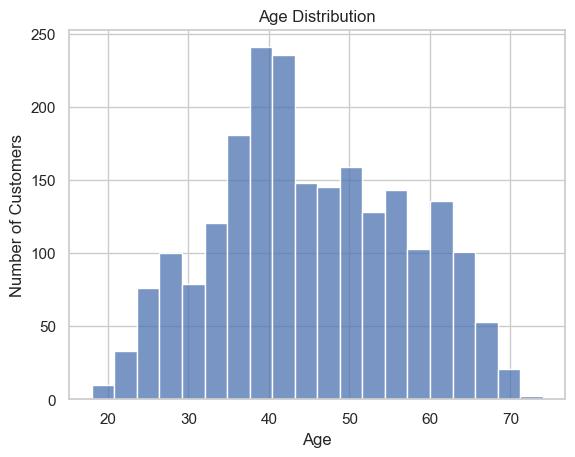

In [179]:
sns.histplot(data=df_clean, x="Age", bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.show()

The newly created **Age** variable ranges from **18 to 74 years**, with a mean age of approximately **45 years**. The distribution presents plausible values with no apparent invalid ages, confirming that the transformation from Year_Birth was successfully performed.

In [180]:
df_clean["Total_Children"] = (df_clean["Kidhome"] + df_clean["Teenhome"])
df_clean["Total_Children"].describe()

count    2216.000000
mean        0.947202
std         0.749062
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Total_Children, dtype: float64

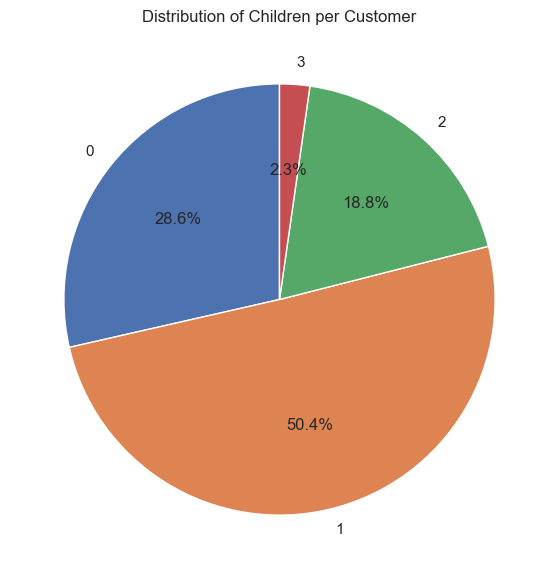

In [181]:

# Count children by customer
children_distribution = (df_clean["Total_Children"].value_counts().sort_index())

# Calculate percentages
children_percentages = (children_distribution / children_distribution.sum() * 100)

# Pie chart
plt.figure(figsize=(9, 7))

plt.pie(
    children_distribution,
    labels=children_percentages.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Children per Customer")
plt.show()

In [182]:
children_percentages

Total_Children
0    28.564982
1    50.406137
2    18.772563
3     2.256318
Name: count, dtype: float64

**Total_Children** shows that only **28.6%** of the customers have no children, the majority of customers have at least one child. The **average number of children is 0.95**, while the **median is 1**.
The distribution is concentrated between 0 and 1 children, with only **2.26%** of customers having three children.
Despite this concentration, household composition may provide relevant information for customer segmentation, as differences in family structure may be associated with different customer needs and purchasing behaviors. Therefore, **Total_Children** will be considered as a potential feature for the clustering model and its contribution will be evaluated during the modeling stage.

### 6.2 From Products Category

In [183]:
df_clean["Total_Spending"] = df_clean[product_cols].sum(axis=1)
df_clean["Total_Spending"].describe()

count    2216.000000
mean      607.075361
std       602.900476
min         5.000000
25%        69.000000
50%       396.500000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64

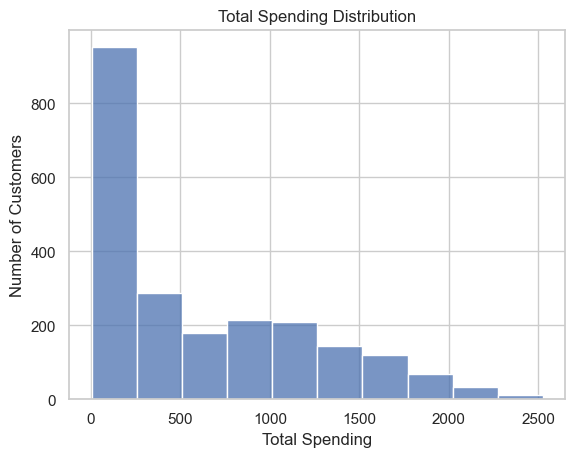

In [184]:
sns.histplot(data=df_clean, x="Total_Spending", bins=10)
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.title("Total Spending Distribution")
plt.show()

The newly created **Total_Spending** variable ranges from 5 to 2,525, with a mean of approximately 607 and a median of 396.5. The difference between the mean and median indicates a right-skewed distribution, with a smaller group of high-spending customers contributing substantially to the overall spending. These high values were retained because they represent potentially meaningful high-value customers rather than invalid observations. The effect of the distribution on clustering will be addressed during the feature preparation and scaling stage.

### 6.3 From Promotion Category

In [186]:
df_clean["Total_Campaign_Accepted"].describe()

count    2216.000000
mean        0.448556
std         0.892440
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: Total_Campaign_Accepted, dtype: float64

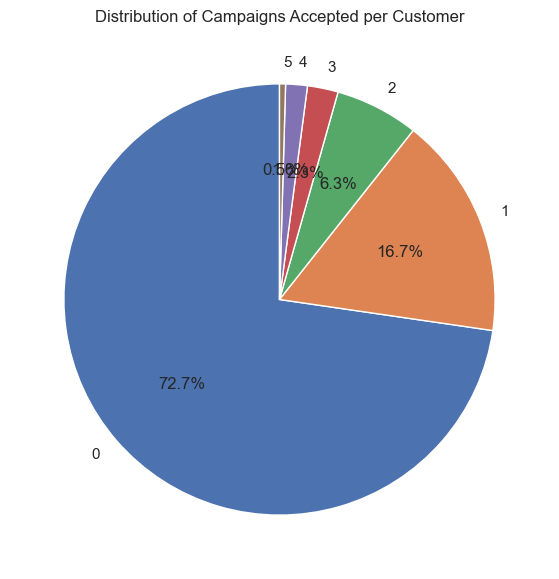

In [187]:
# Count the number of campaigns accepted by each customer
df_clean["Total_Campaigns_Accepted"] = df_clean[campaign_cols].sum(axis=1)

# Count customers by number of campaigns accepted
campaign_distribution = (df_clean["Total_Campaigns_Accepted"].value_counts().sort_index())

# Calculate percentages
campaign_percentages = (campaign_distribution / campaign_distribution.sum() * 100)

# Pie chart
plt.figure(figsize=(9, 7))

plt.pie(
    campaign_percentages,
    labels=[
        f"{i}"
        for i in campaign_percentages.index
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Campaigns Accepted per Customer")
plt.show()

In [188]:
campaign_percentages

Total_Campaigns_Accepted
0    72.698556
1    16.651625
2     6.272563
3     2.301444
4     1.624549
5     0.451264
Name: count, dtype: float64

**Total_Campaigns_Accepted** represents the total number of campaigns accepted by each customer across the six campaigns recorded in the dataset, including the most recent campaign (Response).

The variable shows a highly concentrated distribution toward zero, with a mean of 0.45 accepted campaigns and a median of 0.  **72.7% of customers did not accept any campaign**, while **16.7% accepted one campaign**. Acceptance decreases considerably as the number of campaigns increases, with only **0.45% of customers accepting five out of the six campaigns** recorded in the dataset. This small group represents highly responsive customers toward promotional offers and may be particularly relevant during the customer segmentation analysis.


#### 6.4 From Place Category

In [189]:
df_clean["Total_Purchases"] = df_clean[place_cols].sum(axis=1)


In [191]:
df_clean["Total_Purchases"].describe()

count    2216.000000
mean       12.557310
std         7.204611
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64

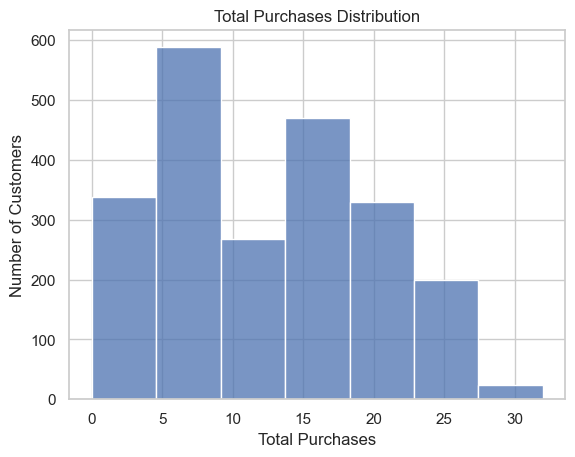

In [192]:
sns.histplot(data=df_clean, x="Total_Purchases", bins=7)
plt.xlabel("Total Purchases")
plt.ylabel("Number of Customers")
plt.title("Total Purchases Distribution")
plt.show()

**Total_Purchases** ranges from 0 to 32 purchases, with a mean of 12.56 and a median of 12. The relatively close values of the mean and median suggest that the distribution does not exhibit strong skewness. However, the distribution shows multiple concentration points, with a large proportion of customers making between approximately 5 and 20 purchases, and a smaller group exceeding 25 purchases. Overall, the variable shows moderate dispersion, with most customers concentrated in the lower-to-middle purchase range and a smaller proportion reaching higher purchase counts. All observed values fall within a plausible range, so no modifications were required for this feature.

## 7. Feature Selection
Before building the model, it´s necessary to define the most important features and determine the contribution of each one for the segmentation result. Each Feature must give relevant information on different dimension for our clients.

### 7.1 Candidate Features
Some features were grouped into one on the Feature Engineering stage, this Features along with Income and NumWebVisitsMonth were selected as candidates for our model.


In [193]:
# Candidate features for customer segmentation

candidate_features = [
    "Age",
    "Income",
    "Total_Children",
    "Total_Spending",
    "Total_Campaign_Accepted",
    "Total_Purchases",
    "NumWebVisitsMonth"
]

df_features = df_clean[candidate_features]

df_features.describe()

,Age,Income,Total_Children,Total_Spending,Total_Campaign_Accepted,Total_Purchases,NumWebVisitsMonth
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,45.081227,51969.595894,0.947202,607.075361,0.448556,12.557310,5.319043
std,11.692358,21521.463961,0.749062,602.900476,0.892440,7.204611,2.425359
min,18.000000,1730.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,37.000000,35303.000000,0.000000,69.000000,0.000000,6.000000,3.000000
50%,44.000000,51377.250000,1.000000,396.500000,0.000000,12.000000,6.000000
75%,55.000000,68487.000000,1.000000,1048.000000,1.000000,18.000000,7.000000
max,74.000000,162397.000000,3.000000,2525.000000,5.000000,32.000000,20.000000


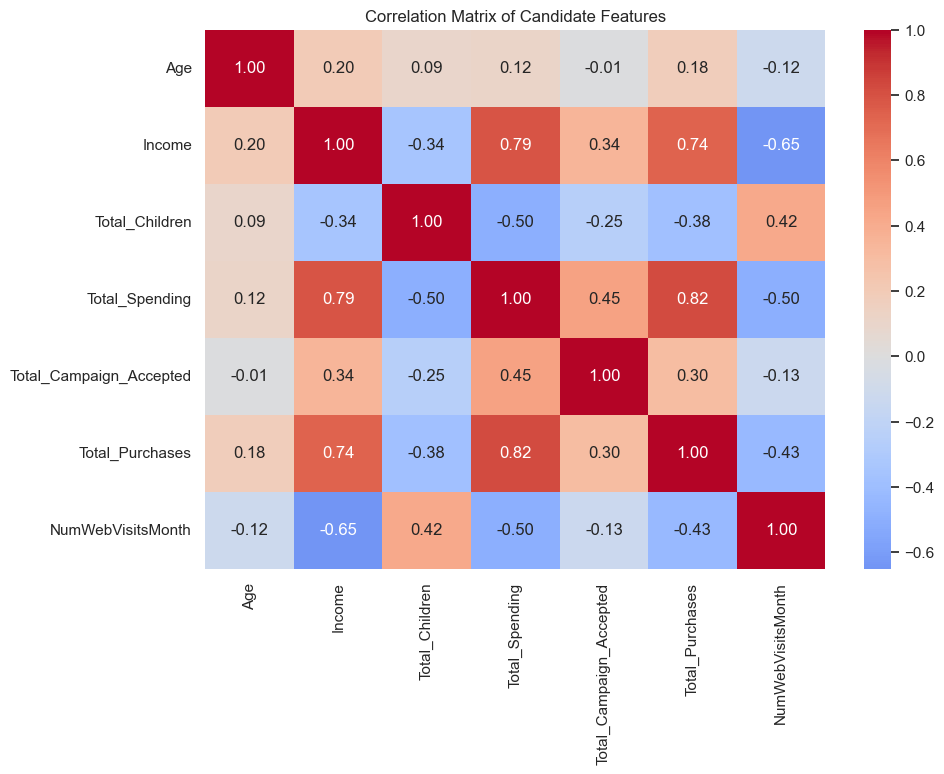

In [194]:
plt.figure(figsize=(10, 7))

corr = df_features.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix of Candidate Features")
plt.show()

A correlation plot shows a strong positive relationship between **Income**, **Total_Spending**, and **Total_Purchases**.

We want to avoid an excessively high correlation between features that provide redundant information, while preserving variables that represent relevant and different dimensions of customer behavior.

To reduce redundant information, **Total_Purchases** was excluded due to its high correlation with Total_Spending (r = 0.82), considering the greater relevance of monetary value for the segmentation objective. While purchase frequency provides useful behavioral information, Total_Spending offers a more direct measure of customer value. Therefore, retaining both variables could introduce redundant information while giving excessive weight to purchasing behavior.

### 7.2 Final Features


In [195]:
final_features = [
    "Age",
    "Income",
    "Total_Children",
    "Total_Spending",
    "Total_Campaigns_Accepted",
    "NumWebVisitsMonth"
]

To define the final set of features, variables were evaluated based on two main criteria: their relevance to the customer segmentation objective and the amount of distinct information they contribute to the customer profile. Features representing substantially different dimensions of customer characteristics or behavior were prioritized, while highly correlated variables with overlapping information were reduced when appropriate.

The final feature set was selected to capture complementary dimensions of the customer profile:

- **Age:** represents the demographic dimension of the customer.
- **Income:** represents the customer's economic capacity and household income level.
- **Total_Children:** represents the family composition of the household and provides information about the customer's family context.
- **Total_Spending:** represents the monetary value of the customer's purchases across the different product categories.
- **Total_Campaigns_Accepted:** represents the customer's responsiveness to promotional campaigns.
- **NumWebVisitsMonth:** represents the customer's level of digital engagement with the company's website.

Together, these features provide a broader representation of customers by combining demographic, economic, family, purchasing, promotional, and digital behavior dimensions.

## 8 Feature Scaling

K-Means clustering is a distance-based algorithm: variables with larger numerical scales could disproportionately influence the resulting clusters. Therefore, the final selected features must be scaled before model training to ensure that each feature contributes on comparable proportions.

### 8.1 Scaling Method

Before aplying any scaler to our features, we must choose the best method according to our features distribution.
 Two options are consdidered for scaling our features: StandardScaler and RobustScaler.


In [196]:
from sklearn.preprocessing import StandardScaler, RobustScaler

In [197]:
df_clean[final_features]

,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
0,57.0,58138.0,0,1617,1,7
1,60.0,46344.0,2,27,0,5
2,49.0,71613.0,0,776,0,4
3,30.0,26646.0,1,53,0,6
4,33.0,58293.0,1,422,0,5
...,...,...,...,...,...,...
2235,47.0,61223.0,1,1341,0,5
2236,68.0,64014.0,3,444,1,7
2237,33.0,56981.0,0,1241,1,6
2238,58.0,69245.0,1,843,0,3


In [198]:
# Aplying each method to final features

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_standard = standard_scaler.fit_transform(
    df_clean[final_features]
)

X_robust = robust_scaler.fit_transform(
    df_clean[final_features]
)

In [199]:
# Data Frame Transformation
df_standard = pd.DataFrame( X_standard,
    columns=final_features,
    index=df_clean.index)

df_robust = pd.DataFrame(  X_robust,
    columns=final_features,
    index=df_clean.index)

In [200]:
df_standard.describe()

,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
count,2.216000e+03,2.216000e+03,2.216000e+03,2.216000e+03,2.216000e+03,2.216000e+03
mean,-9.779582e-17,-4.328667e-17,-2.565136e-17,1.442889e-17,6.813643e-17,-5.771557e-17
std,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00
min,-2.316670e+00,-2.334922e+00,-1.264803e+00,-9.988568e-01,-5.027309e-01,-2.193591e+00
25%,-6.913106e-01,-7.745922e-01,-1.264803e+00,-8.926794e-01,-5.027309e-01,-9.563810e-01
50%,-9.249387e-02,-2.752971e-02,7.050118e-02,-3.493494e-01,-5.027309e-01,2.808287e-01
75%,8.485039e-01,7.676584e-01,7.050118e-02,7.315041e-01,6.180454e-01,6.932320e-01
max,2.473864e+00,5.132194e+00,2.741110e+00,3.181881e+00,5.101150e+00,6.054474e+00


In [201]:
df_robust.describe()

,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,0.060068,0.017850,-0.052798,0.215092,0.448556,-0.170239
std,0.649575,0.648549,0.749062,0.615833,0.892440,0.606340
min,-1.444444,-1.496120,-1.000000,-0.399898,0.000000,-1.500000
25%,-0.388889,-0.484398,-1.000000,-0.334525,0.000000,-0.750000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.611111,0.515602,0.000000,0.665475,1.000000,0.250000
max,1.666667,3.345581,2.000000,2.174157,5.000000,3.500000


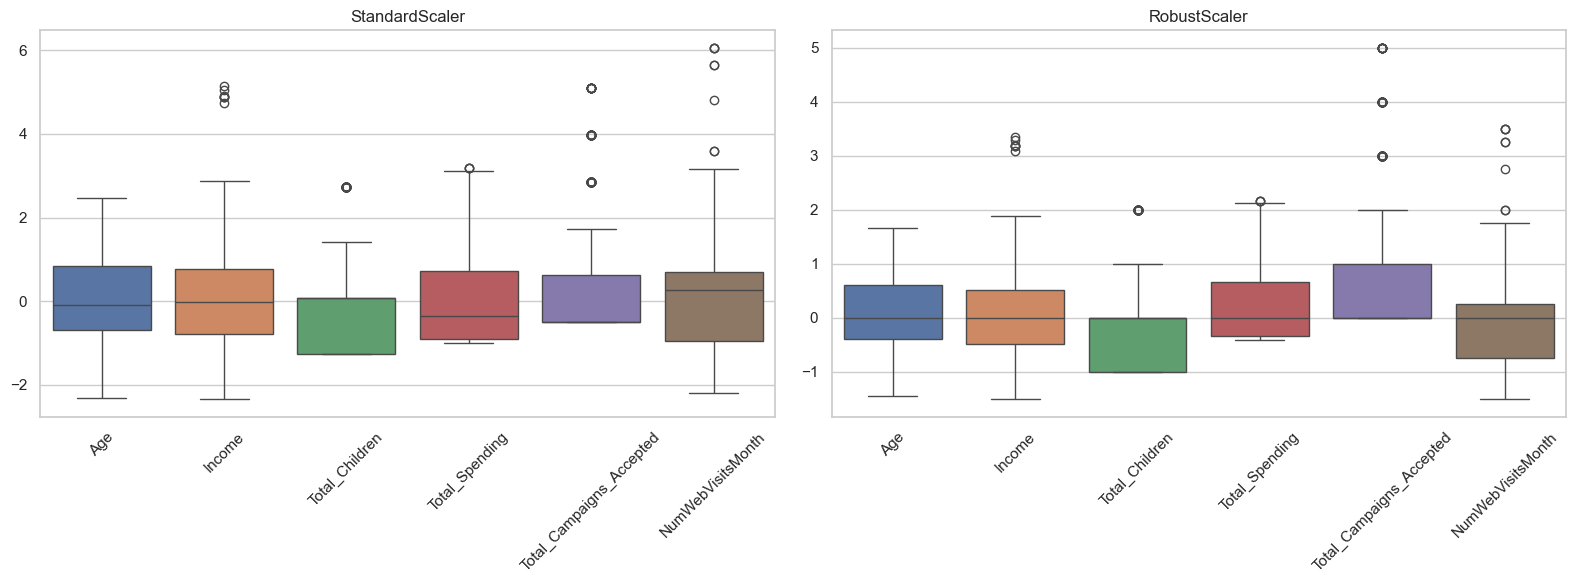

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_standard, ax=axes[0])
axes[0].set_title("StandardScaler")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_robust, ax=axes[1])
axes[1].set_title("RobustScaler")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 8.2 Scaler Selection

Both **StandardScaler** and **RobustScaler** were evaluated statistically with the describe() function and visually with boxplots, in order to determine the most appropriate scaling method for the selected features.

**StandardScaler** successfully standardized the variables to a mean close to zero and a standard deviation close to one; however, several features presented relatively extreme values after transformation, particularly **Income** and **NumWebVisitsMonth**. Since these features contain valid observations with asymmetric distributions and potential outliers, using the mean and standard deviation as scaling parameters may allow extreme observations impact more on the Euclidean distances used by K-Means.

**RobustScaler** was therefore selected because it uses the median and interquartile range, making the scaling less sensitive to extreme observations while preserving them in the dataset. This approach allows the model to keep potentially meaningful high-value customers without allowing a small number of extreme observations to disproportionately determine the scale of the features.



In [203]:
# Final features selected for the model
X = df_clean[final_features]

# Aplication of the selected scaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Convertion to DataFrame
X_scaled = pd.DataFrame( X_scaled,
    columns=final_features,
    index=X.index)

Before entering the model we must make a last sanity check to this final DataFrame, in order to be sure K-Means will work correctly.

In [204]:
X_scaled.head()

,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
0,0.722222,0.203735,-1.0,1.246680,1.0,0.25
1,0.888889,-0.151677,1.0,-0.377426,0.0,-0.25
2,0.277778,0.609804,-1.0,0.387640,0.0,-0.50
3,-0.777778,-0.745276,0.0,-0.350868,0.0,0.00
4,-0.611111,0.208406,0.0,0.026047,0.0,-0.25


In [205]:
# No nulls
X_scaled.isna().sum()

Age                         0
Income                      0
Total_Children              0
Total_Spending              0
Total_Campaigns_Accepted    0
NumWebVisitsMonth           0
dtype: int64

In [206]:
# Only numerical features
X_scaled.dtypes

Age                         float64
Income                      float64
Total_Children              float64
Total_Spending              float64
Total_Campaigns_Accepted    float64
NumWebVisitsMonth           float64
dtype: object

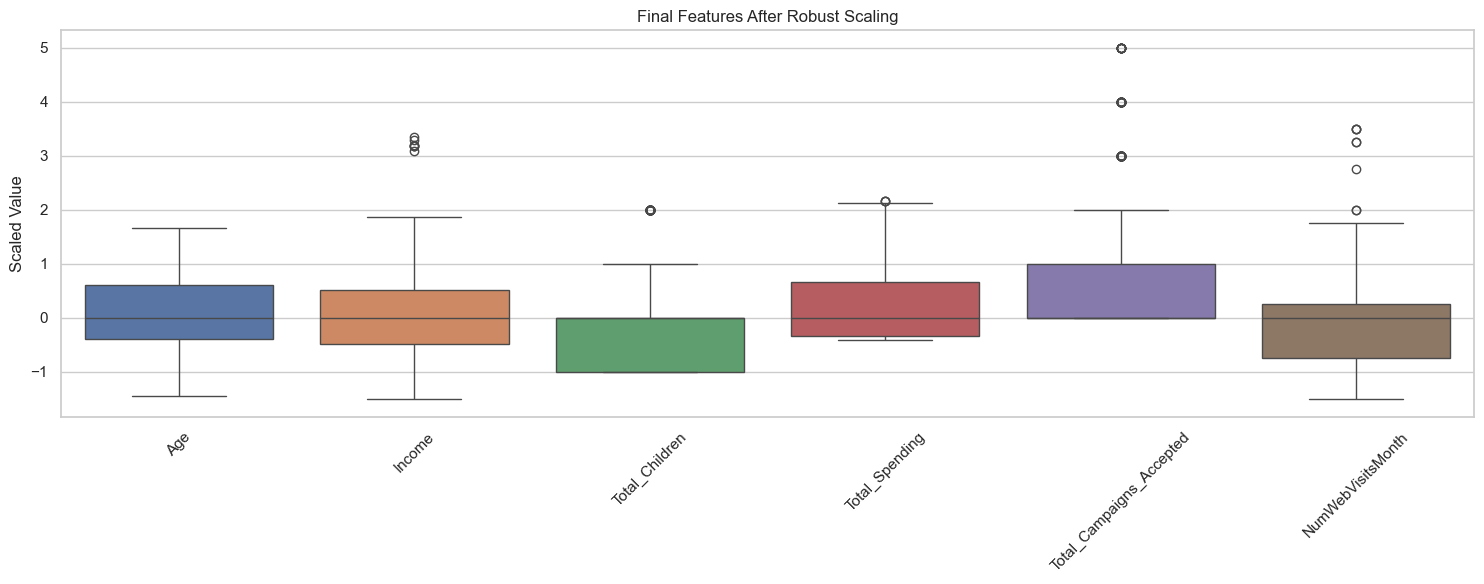

In [207]:
plt.figure(figsize=(15, 6))

sns.boxplot(data=X_scaled)

plt.xticks(rotation=45)
plt.title("Final Features After Robust Scaling")
plt.ylabel("Scaled Value")

plt.tight_layout()
plt.show()

## 9.Clustering

With the features correctly selected and scaled, the next step is to apply K-Means clustering in order to identify meaningful customer segments.

 K-Means requires the number of clusters to be specified in advance. therefore different values of **k** will be evaluated to determine which segmentation provides the most appropriate balance between cluster compactness, separation, cohesion and interpretability.


### 9.1 Training K-Means models

To evaluate different segmentation alternatives, various K-Means models were trained using values of **k** ranging from 2 to 10. For each value of **k**, the model was fitted using the selected scaled features, creating the clusters and assinging each customer one respectively.

Two evaluation metrics were calculated for each model: **Inertia and the Silhouette Score**:
 * The **Inertia** measures the compactness of the clusters by calculating the sum of squared distances between observations and their assigned cluster centroids. Lower inertia values indicate more compact clusters; however, inertia naturally decreases as the number of clusters increases. Therefore, it should not be used independently to select the optimal number of clusters.

* The **Silhouette Score** evaluates both the cohesion within clusters and the separation between different clusters. Higher values indicate that observations are generally more similar to members of their own cluster than to observations in other clusters.

By analyzing both metrics together, it is possible to identify values of k that provide a reasonable balance between cluster quality and segmentation complexity.


In [208]:
#Import libraries for K-means clustering and Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# We consider a range of 2 to 10 for our possible Number of Clusters
k_values = range(2, 11)

# We initialize an empty list for Inertia and Silhouette Score
inertia = []
silhouette_scores = []

# Iteration for each K value
for k in k_values:
    #Builds the K-means model for each number of clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    #Trains the model using the scaled features: creates clusters and assigns one to each customer
    clusters = kmeans.fit_predict(X_scaled)

    #Storages the inertia value for each K
    inertia.append(kmeans.inertia_)

    #Uses scaled features and trained model to evaluate quality of the clusters for cohesion and separation
    score = silhouette_score( X_scaled, clusters)
    silhouette_scores.append(score)



The results obtained from the different K-Means models were then visualized using the Elbow Method for **Inertia** and the **Silhouette Score** for each **k**. These two approaches provide complementary perspectives for evaluating the potential number of customer segments.


#### 9.1.1 Inertia Evaluation by Elbow Method

The Elbow Method examines how **Inertia** changes as the number of clusters increases. Knowing that adding more clusters naturally reduces the distance between observations and their assigned centroids, inertia is expected to decrease continuously.

Therefore, the objective is not to locate the lowest value, is to identify at which point the improvement decreases significantly. This point is commonly referred to as the "elbow" and represents a potential balance between model complexity and cluster compactness.


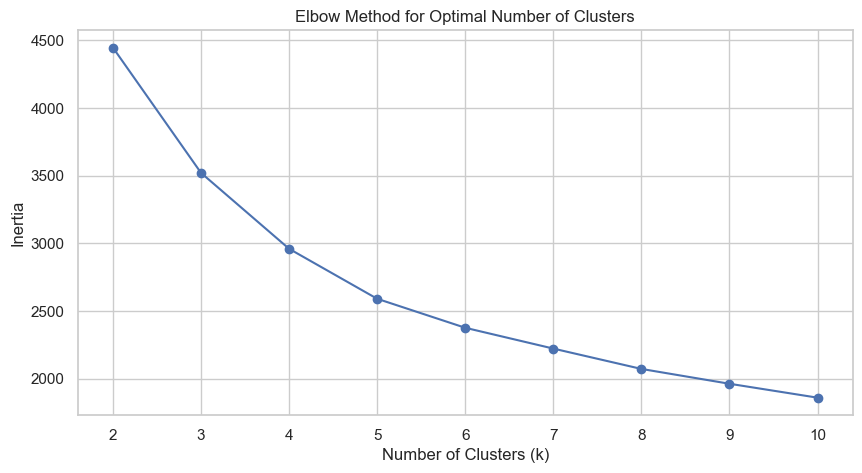

In [209]:
#Plotting Inertia per K-value
plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

The curve begins to show a more gradual decrease around **k = 4** and **k = 6**, suggesting that this range may represent a reasonable balance between improving cluster compactness and increasing the segmentation complexity.

This range was therefore considered relevant for further evaluation. Since the Elbow Method does not provide a clearly defined single optimal value in this case, additional metrics and qualitative characteristics of the resulting clusters must be considered before selecting the final segmentation.


#### 9.1.2 Silhouette Score

While the **Inertia** focuses on cluster compactness, the **Silhouette Score** provides additional information about the separation between clusters. The score considers both how closely observations are grouped within their own cluster and how distinct they are from observations belonging to other clusters.

A higher Silhouette Score generally indicates well defined clusters. For this reason, the metric is particularly useful for comparing different values of **k** and evaluating whether increasing the number of clusters results in a meaningful improvement in segmentation quality.


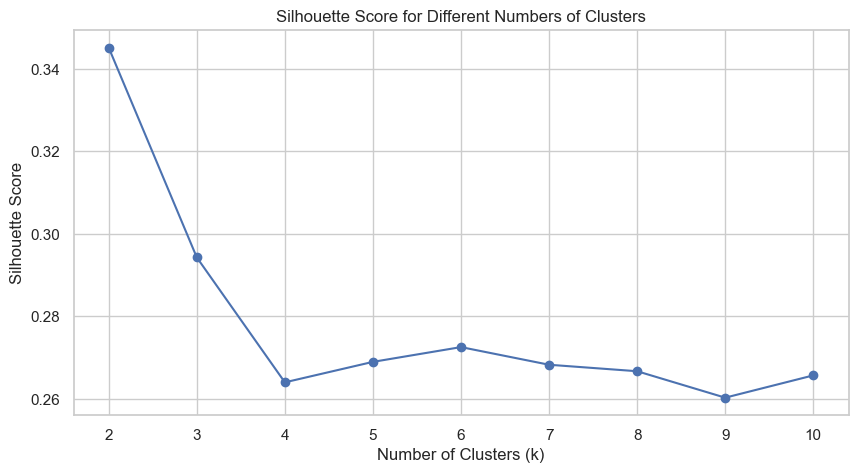

In [210]:
# Plotting Silhouette Score per K-value
plt.figure(figsize=(10, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.show()

The results show that **k = 2** achieves the highest **Silhouette Score** on **0.345**, indicating the strongest cluster separation among the evaluated models. The score decreases considerably when moving to **k = 3** and remains relatively stable between approximately **0.26** and **0.27** for higher values of **k**.

Among the models with more than three clusters, **k = 6** achieves the highest on **0.273**. This makes it an interesting candidate because it provides a more detailed segmentation while maintaining a relatively stronger cluster structure compared with the other higher values of **k**.
The Inertia curve decreases substantially as the number of clusters increases, particularly during the initial values of **k**. However, the improvement begins to become more gradual around **k = 4 to k = 6**.

This range was therefore considered relevant for further evaluation. Since the Elbow Method does not provide a clearly defined single optimal value in this case, additional metrics and qualitative characteristics of the resulting clusters must be considered before selecting the final segmentation.


#### 9.1.2 Candidate Model Selection

To facilitate the comparison between the different K-Means models, the **Inertia** and **Silhouette Score** obtained for each value of **k** were summarized in the following table.


In [211]:
k_results = pd.DataFrame({
    "k": k_values,
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores})

k_results

,k,Inertia,Silhouette Score
0,2,4445.902179,0.345134
1,3,3520.093291,0.294303
2,4,2958.986436,0.264030
3,5,2589.491071,0.268992
4,6,2375.084261,0.272571
5,7,2221.281296,0.268295
6,8,2070.867971,0.266723
7,9,1961.279336,0.260315
8,10,1858.393313,0.265713



The evaluation of the different K-Means models does not point to a single optimal value of k based exclusively on one metric. The **Elbow Method** suggests that the improvement in cluster compactness begins to decrease around the range of**k = 4** and **k=6**, while the **Silhouette Score** clearly favors **k = 2**.

Although **k = 2** provides the strongest statistical separation according to the **Silhouette Score**, a two cluster solution may oversimplify customer behavior. Therefore, values with stronger statistical performance and values located near the potential elbow should be considered for further analysis.

For this reason, **k = 2, 3, 4, 5, and 6** were selected as candidate solutions for further evaluation. In addition to their statistical metrics, the candidate models will be evaluated based on cluster size, customer profiles, and the practical interpretability of the resulting segments.


### 9.2 Evaluation by Cluster Size

**Inertia** and the **Silhouette Score** provide quantitative measures of model performance, but they do not show how customers are distributed among the resulting clusters. Therefore, analyzing the distribution of customers across clusters provides an additional perspective on the segmentation produced by each candidate model.

Based on the results obtained in the previous evaluation, **k = 2, 3, 4, 5 and 6** were selected as candidate solutions for further analysis. The corresponding K-Means models were trained and stored in order to examine their cluster assignments, sizes, and customer distributions.

In [212]:
#Selected values of K according Inertia and Silhouette Score Analysis
candidate_k = [2, 3, 4, 5, 6]

# Creating an empty dictionary for the models
candidate_models = {}

# Builds a dictionary for each K containing the model itself, the cluster label for each customer, the Inertia and Silhouette score.
for k in candidate_k:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    clusters = kmeans.fit_predict(X_scaled)
    candidate_models[k] = {
        "model": kmeans,
        "labels": clusters,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_scaled,clusters)}

Each candidate model was stored together with its cluster assignments and evaluation metrics. Storing these results allows the subsequent analyses to access the same model outputs without repeatedly fitting the models.

In [213]:
#Counting the size of each cluster for each K model
cluster_sizes = {}

for k in candidate_k:
    labels = candidate_models[k]["labels"]
    cluster_sizes[k] = pd.Series(labels).value_counts().sort_index()

In [214]:
#Calculating the percentage distribution for each cluster for each model
cluster_percentages = {}

for k, sizes in cluster_sizes.items():
    percentages = (sizes / sizes.sum()) * 100
    cluster_percentages[k] = percentages

The resulting cluster distributions are presented both numerically and visually. This comparison helps identify highly unbalanced segmentations or very small clusters that may require additional examination during the model selection process.

In [215]:
#Building a table that shows the size and percentage for each cluster for each model
for k in candidate_k:
    cluster_distribution = pd.DataFrame({
        "Customers": cluster_sizes[k],
        "Percentage": cluster_percentages[k]})

    print(f"\nCluster distribution for k = {k}")
    display(cluster_distribution)


Cluster distribution for k = 2


,Customers,Percentage
0,1555,70.17148
1,661,29.82852



Cluster distribution for k = 3


,Customers,Percentage
0,732,33.032491
1,1285,57.987365
2,199,8.980144



Cluster distribution for k = 4


,Customers,Percentage
0,711,32.084838
1,728,32.851986
2,196,8.844765
3,581,26.218412



Cluster distribution for k = 5


,Customers,Percentage
0,194,8.754513
1,446,20.126354
2,640,28.880866
3,579,26.128159
4,357,16.110108



Cluster distribution for k = 6


,Customers,Percentage
0,586,26.444043
1,209,9.431408
2,431,19.449458
3,493,22.247292
4,347,15.658845
5,150,6.768953


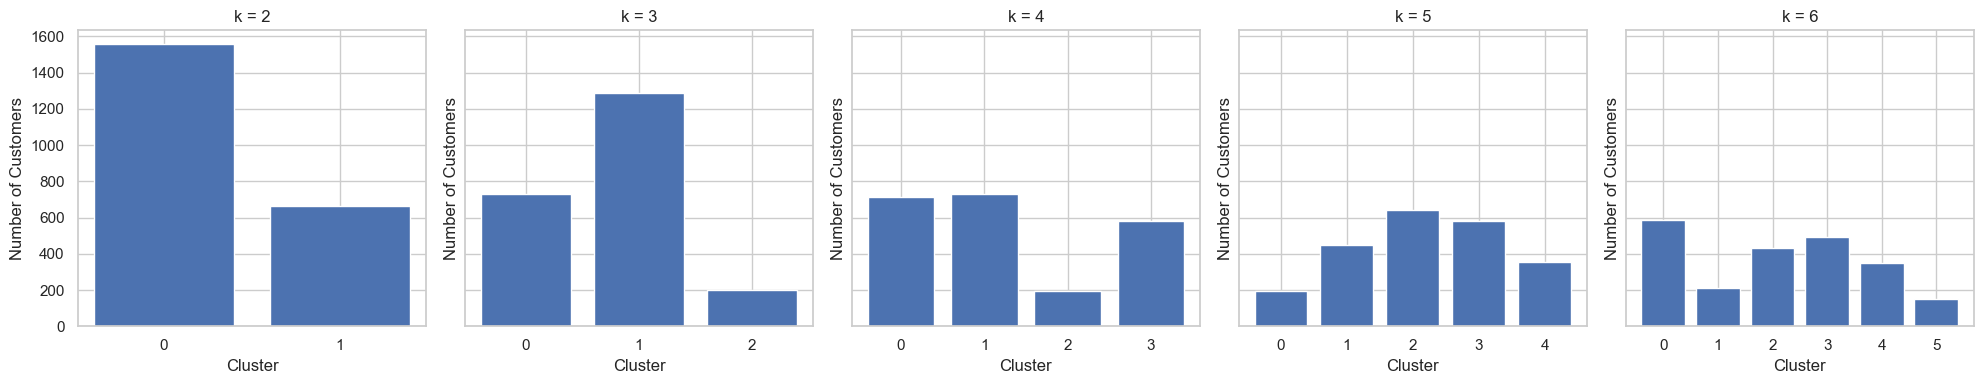

In [216]:

#Plotting the distributio by cluster for each model
fig, axes = plt.subplots(1, len(candidate_k), figsize=(20, 4), sharey=True)

for ax, k in zip(axes, candidate_k):
    sizes = cluster_sizes[k]
    ax.bar(sizes.index.astype(str), sizes.values)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of Customers")
    ax.set_title(f"k = {k}")

plt.tight_layout()
plt.show()

The distribution of customers varies across the candidate models:
* The **k = 2** solution produces two relatively broad groups, with approximately 70% of customers concentrated in one cluster.
* The **k = 3** model contains one dominant cluster and one relatively small segment.
* The **k = 4** model features two predominant, well-balanced clusters, a moderate third cluster and a minority cluster.
* The **k = 5** solution produces a more balanced distribution across  clusters, with not one cluster containing a disproportionately large part of customers. One segment represents less than 10% of the dataset, the remaining clusters are distributed more evenly.
* The **k = 6** model provides a more granular segmentation by introducing smaller clusters. The smallest cluster represents approximately 6.8% of the customers, which is not necessarily problematic, but its practical relevance must be evaluated through the customer profiles.

Therefore, cluster size alone is not enough to determine the optimal number of clusters. A smaller segment may represent a meaningful and valuable customer group, while a balanced distribution does not necessarily guarantee that the resulting clusters are behaviorally distinct. For this reason, the next stage evaluates the customer profiles associated with each candidate model.

### 9.3 Evaluation by Cluster Profile
The selected K-Means models were further evaluated by examining the average values of the final features within each cluster.

Cluster size provides information about the numerical distribution of customers, but it does not explain what differentiates one segment from another.

To better understand the resulting segmentation, the average values of the final selected features were calculated for each cluster. This analysis reveals meaningful characteristics for each cluster and interpretable differences in customer demographics, economic value, purchasing behavior, campaign responsiveness, and digital activity.


In [217]:
#Create a copy of the original dataset for selected features
profile_df = df_clean[final_features].copy()

#Dictionary to store the clusters profiles for each K model
cluster_profiles = {}


for k in candidate_k:
    #Add a Cluster column assigned to each customer
    profile_df["Cluster"] = candidate_models[k]["labels"]
    #Calculate the mean of each feature feature for every cluster
    cluster_profile = profile_df.groupby("Cluster")[final_features].mean()
    #Obtaining the size of each cluster by counting the customers
    cluster_profile["Customers"] = (
        profile_df["Cluster"].value_counts().sort_index())
    cluster_profile = cluster_profile[["Customers"] + final_features]

     # Store the profile for each value of k
    cluster_profiles[k] = cluster_profile

The resulting profiles provide an important qualitative perspective for evaluating whether the clusters represent distinct and interpretable customer segments.


In [218]:
cluster_profiles[2]

,Customers,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
Cluster,,,,,,,
0,1555,44.329904,42051.022830,1.232154,299.111254,0.171061,6.223151
1,661,46.848714,75303.001513,0.276853,1331.559758,1.101362,3.192133


For **k = 2**:

**Cluster 0**
* Lower average income.
* Higher number of children in the household, with more than one child on average.
* Lower Total Spending.
* Limited campaign acceptance.
* Higher website activity compared with the other cluster.
* Represents a larger group of lower-value and digitally active customers.

**Cluster 1**
* Substantially higher average income.
* Higher Total Spending.
* Fewer children in the household.
* Greater receptiveness to marketing campaigns.
* Lower website activity.
* Represents a smaller but higher-value customer segment.

In [219]:
cluster_profiles[3]

,Customers,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
Cluster,,,,,,,
0,732,48.250000,69969.228142,0.501366,1086.566940,0.262295,3.449454
1,1285,43.294942,37972.556031,1.297276,200.150973,0.195331,6.589105
2,199,44.959799,76142.788945,0.326633,1470.944724,2.768844,3.994975


For **k = 3**, the additional cluster provides a more detailed segmentation compared with the two-cluster solution.

**Cluster 0** represents high-value customers who are less responsive to promotional campaigns.

* Medium-high average income.
* High Total Spending.
* Low campaign acceptance.
* Relatively few children.
* Lower digital activity.


**Cluster 1** represents lower-value customers with larger households and higher digital activity.

* Lower average income.
* More than one child on average.
* Very low Total Spending.
* Lowest campaign acceptance.
* Highest website activity among the groups.

**Cluster 2** represents the highest-value and most promotion-responsive customer segment.

* Highest average income.
* Highest Total Spending.
* Lowest number of children.
* Substantially higher campaign acceptance.
* Moderate website activity.


Compared to **k=2**, the three-segment solution divides the high-value customers segment by it´s responsiveness to marketing strategies.

In [234]:
cluster_profiles[4]


,Customers,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
Cluster,,,,,,,
0,711,37.599156,32058.470464,0.822785,156.475387,0.198312,6.818565
1,728,48.070055,70118.532967,0.501374,1084.782967,0.262363,3.468407
2,196,44.637755,76307.010204,0.306122,1478.857143,2.780612,3.948980
3,581,50.641997,45384.829604,1.874355,265.829604,0.201377,6.265060


For **k=4**

**Cluster 0** represents younger customers with relatively low purchasing value but high digital engagement.
* The youngest segment.
* Lowest average income
* Lowest Total Spending.
* Less than one child on average.
* Lowest campaign acceptance.
* Highest website activity.

**Cluster 1** represents valuable customers who spend significantly but are not particularly responsive to promotional campaigns.
* High average income.
* High Total Spending.
* Low number of children.
* Low campaign acceptance despite their high customer value.
* Low website activity.

**Cluster 2** represents the most valuable and highly responsive customer segment.
* Highest average income.
* Highest Total Spending.
* Very few children.
* Highest campaign acceptance.
* Moderate website activity.

**Cluster 3** represents customers with larger households and relatively low purchasing value.
* The oldest segment.
* Moderate-to-low income.
* Low Total Spending.
* Highest number of children.
* Low campaign acceptance.
* High website activity.



In [220]:
cluster_profiles[5]

,Customers,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
Cluster,,,,,,,
0,194,44.628866,76720.525773,0.304124,1489.391753,2.788660,3.938144
1,446,48.569507,43552.587444,2.112108,214.417040,0.213004,6.360987
2,640,36.540625,30404.178906,0.828125,131.296875,0.207813,6.937500
3,579,51.455959,58669.202073,0.939551,713.727116,0.167530,5.050086
4,357,45.941176,76829.820728,0.067227,1298.120448,0.358543,2.302521


For **k = 5**
**Cluster 0** represents high-value customers who are highly receptive to promotional campaigns.
* Highest Income.
* Highest Total Spending.
* Very few children.
* Highest campaign acceptance.
* Moderate website activity.

**Cluster 1**  represents larger households with limited purchasing value.
* Moderate-to-low income.
* Highest number of children.
* Low Total Spending.
* Very low campaign acceptance.
* High website activity.

**Cluster 2** represents younger and lower-value customers with high digital activity.
* Youngest segment.
* Lowest average income.
* Lowest Total Spending.
* Less than one child on average.
* Low campaign acceptance.
* Highest website activity.

**Cluster 3** represents oldest customers with intermediate purchasing value but limited promotional responsiveness.
* Oldest segment.
* Moderate income.
* Intermediate Total Spending.
* Approximately one child.
* Very low campaign acceptance.
* Moderate website activity.

**Cluster 4** represents high-value customers with low household responsibilities and limited website activity.
* High average income.
* High Total Spending.
* Almost no children.
* Moderate campaign acceptance.
* Lowest website activity.

In [221]:
cluster_profiles[6]

,Customers,Age,Income,Total_Children,Total_Spending,Total_Campaigns_Accepted,NumWebVisitsMonth
Cluster,,,,,,,
0,586,36.240614,29995.133959,0.827645,121.469283,0.097270,6.914676
1,209,48.200957,52847.885167,0.961722,721.655502,1.440191,6.574163
2,431,48.545244,43263.890951,2.111369,202.313225,0.153132,6.345708
3,493,51.085193,58508.117647,0.931034,681.432049,0.000000,4.837728
4,347,46.066282,77256.881844,0.063401,1307.244957,0.357349,2.233429
5,150,43.306667,81619.273333,0.146667,1643.433333,2.973333,3.106667


For **k = 6**

**Cluster 0** represents young, low-value, and digitally active customers.
* Youngest segment.
* Lowest income.
* Lowest Total Spending.
* Less than one child on average.
* Very low campaign acceptance.
* Highest website activity.

**Cluster 1** represents customers with moderate purchasing value but relatively strong responsiveness to promotions.

* Intermediate income.
* Intermediate Total Spending.
* Approximately one child.
* High campaign acceptance.
* High website activity.

**Cluster 2** represents larger households with relatively low customer value.
* Low income.
* Low Total Spending.
* Highest number of children.
* Very low campaign acceptance.
* High website activity.

**Cluster 3** represents oldest customers with intermediate purchasing value and extremely limited responsiveness to promotions.

* Oldest segment.
* Moderate income.
* Intermediate Total Spending.
* Approximately one child.
* No campaign acceptance on average.
* Moderate website activity.

**Cluster 4** represents high-value customers with no children and limited digital activity.

* High income.
* High Total Spending.
* Almost no children.
* Moderate campaign acceptance.
* Lowest website activity.

**Cluster 5** represents the premium customer segment with exceptionally high value and responsiveness to marketing campaigns.

* Highest income.
* Highest Total Spending.
* Very few children.
* Highest campaign acceptance.
* Low website activity.

### 9.4 Clusters Visualization and Separation Analysis

Quantitative metrics such as Inertia and the Silhouette Score provide valuable information about model performance. However, visualizing the cluster structure can provide additional insight into how customers are distributed and how clearly the resulting groups are separated.

Since the clustering model uses six scaled features, Principal Component Analysis (PCA) was applied to reduce the data to two dimensions for visualization purposes.

It is important to note that PCA does not alter the clustering model itself. The K-Means models were trained using the complete scaled feature space. PCA is used only to project the customers and cluster centroids into a two-dimensional space that allows the cluster structure to be visually examined.

#### 9.4.1 PCA Visualization (Principal Componeny Analysis trasformation)

The candidate models were trained using six scaled features, which makes it difficult to directly visualize the cluster structure in its original feature space.

To provide a visual representation of the segmentation, **Principal Component Analysis (PCA) transformation** was applied to reduce the six-dimensional scaled feature space to two principal components.

The PCA transformation is used exclusively for visualization purposes. The K-Means models were trained using the complete scaled feature space, only the cluster assignments were plotted in a two-dimensional PCA representation.

In [223]:
from sklearn.decomposition import PCA
# Applying PCA (Principal Component Analysis) to reduce the scaled features to two principal components for visualization.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [224]:
# Percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

print( f"Principal Component 1: {explained_variance[0]:.2%}")
print( f"Principal Component 2: {explained_variance[1]:.2%}")
print( f"Total variance explained: {explained_variance.sum():.2%}")

Principal Component 1: 45.55%
Principal Component 2: 20.39%
Total variance explained: 65.93%


The first two principal components explain approximately **65.93%** of the total variance in the scaled dataset.
|
Although the two-dimensional representation does not preserve all of the information contained in the original six-dimensional feature space, it provides a useful visual approximation of the overall structure of the customer data and the relative distribution of the clusters.

In [225]:
# PCA loadings for each feature
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["Principal Component 1", "Principal Component 2"],
    index=final_features)

pca_loadings

,Principal Component 1,Principal Component 2
Age,0.057752,-0.230619
Income,0.448272,-0.272738
Total_Children,-0.425772,0.234918
Total_Spending,0.456971,-0.135616
Total_Campaigns_Accepted,0.545436,0.793519
NumWebVisitsMonth,-0.328802,0.411313


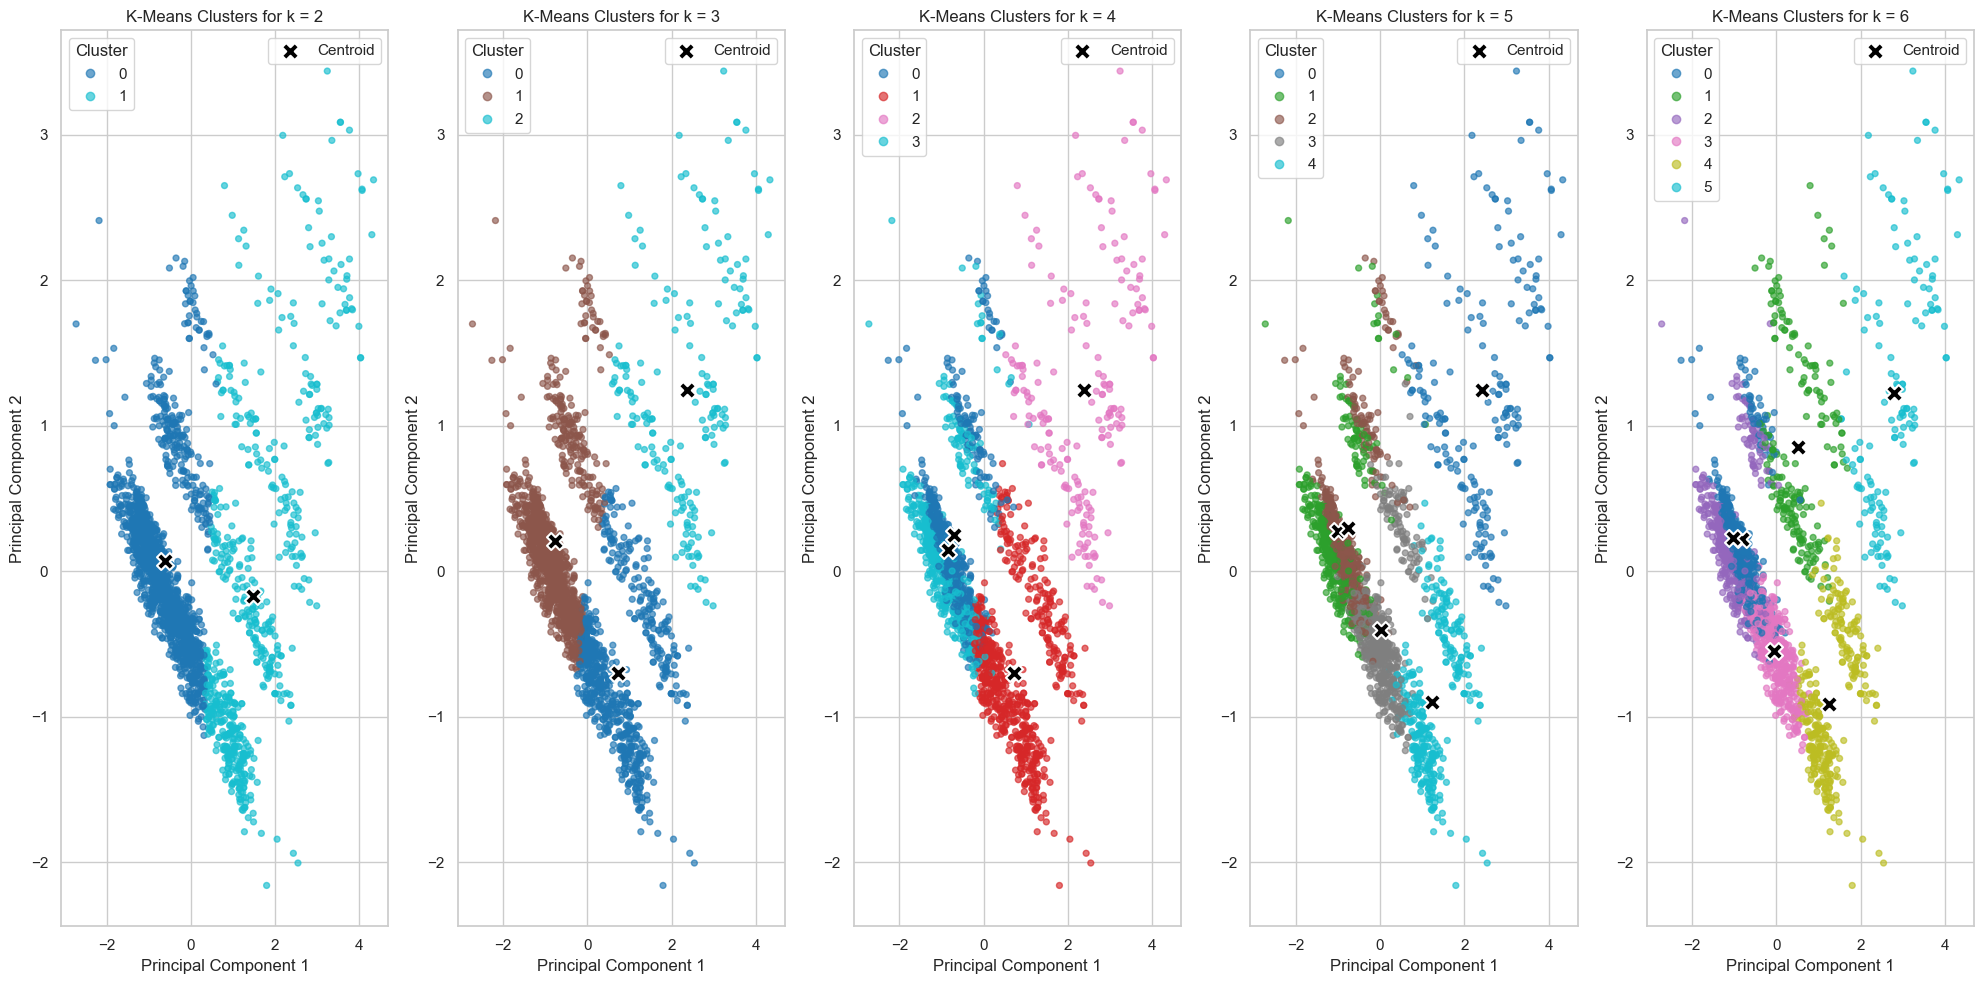

In [231]:
fig, axes = plt.subplots(1, 5, figsize=(20, 10))

for ax, k in zip(axes.flatten(), candidate_k):

    # Cluster labels
    labels = candidate_models[k]["labels"]

    # K-Means model
    model = candidate_models[k]["model"]

    # Project cluster centroids into the PCA space
    centroids_df = pd.DataFrame(model.cluster_centers_, columns=pca.feature_names_in_)
    centroids_pca = pca.transform(centroids_df)

    # Plot customers
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.65,
        s=18
    )

    # Plot centroids
    ax.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        c="black",
        marker="X",
        s=150,
        edgecolors="white",
        linewidths=1.5,
        label="Centroid"
    )

    ax.set_title(f"K-Means Clusters for k = {k}")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

    # Cluster legend
    cluster_legend = ax.legend(
        *scatter.legend_elements(),
        title="Cluster",
        loc="best"
    )

    ax.add_artist(cluster_legend)

    # Centroid legend
    ax.legend(
        loc="upper right"
    )

plt.tight_layout()
plt.show()

The PCA visualizations provide a complementary perspective on the candidate models by showing how the customer observations are distributed in a reduced two-dimensional space.

Some degree of overlap between clusters is expected because the original segmentation was created using six dimensions, while the visualization represents only two principal components. Therefore, apparent overlap in the PCA plot does not necessarily indicate that the clusters are incorrectly defined in the complete feature space.

For this reason, the visual analysis should be interpreted together with the statistical measures of cluster separation.

#### 9.4.2 Centroid Distance Analysis

To complement the PCA visualization, the distances between cluster centroids were calculated in the original scaled feature space used for training the K-Means models.

Centroid distances provides an additional measure of how separated the central profiles are from the rest the clusters. Larger distances generally indicate greater separation between cluster centers, while smaller distances may suggest that two clusters represent relatively similar customer profiles.


In [227]:
# Dictionary to store centroid distance matrices
from sklearn.metrics import pairwise_distances
centroid_distances = {}

for k in candidate_k:

    # Retrieve the trained K-Means model
    model = candidate_models[k]["model"]

    # Calculate the distances between all cluster centroids
    distances = pairwise_distances(model.cluster_centers_)

    # Store the distance matrix as a DataFrame
    centroid_distances[k] = pd.DataFrame(
        distances,
        index=[f"Cluster {i}" for i in range(k)],
        columns=[f"Cluster {i}" for i in range(k)]
    )


for k in candidate_k:
    print(f"\nCentroid distances for k = {k}")
    display(centroid_distances[k])


Centroid distances for k = 2


,Cluster 0,Cluster 1
Cluster 0,0.000000,2.120343
Cluster 1,2.120343,0.000000



Centroid distances for k = 3


,Cluster 0,Cluster 1,Cluster 2
Cluster 0,0.000000,1.754807,2.560097
Cluster 1,1.754807,0.000000,3.316973
Cluster 2,2.560097,3.316973,0.000000



Centroid distances for k = 4


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Cluster 0,0.000000,1.834694,3.347437,1.349480
Cluster 1,1.834694,0.000000,2.573978,1.911039
Cluster 2,3.347437,2.573978,0.000000,3.457622
Cluster 3,1.349480,1.911039,3.457622,0.000000



Centroid distances for k = 5


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Cluster 0,0.000000,3.607312,3.401767,2.901530,2.484409
Cluster 1,3.607312,0.000000,1.510034,1.406312,2.735772
Cluster 2,3.401767,1.510034,0.000000,1.415186,2.365363
Cluster 3,2.901530,1.406312,1.415186,0.000000,1.420898
Cluster 4,2.484409,2.735772,2.365363,1.420898,0.000000



Centroid distances for k = 6


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
Cluster 0,0.000000,1.766432,1.518321,1.426651,2.411387,3.825295
Cluster 1,1.766432,0.000000,1.829388,1.523155,2.017438,2.340618
Cluster 2,1.518321,1.829388,0.000000,1.424506,2.763139,4.007099
Cluster 3,1.426651,1.523155,1.424506,0.000000,1.452574,3.358660
Cluster 4,2.411387,2.017438,2.763139,1.452574,0.000000,2.656441
Cluster 5,3.825295,2.340618,4.007099,3.358660,2.656441,0.000000


The centroid distance matrices provide a detailed view of the relative separation between clusters.

The results show that increasing the number of clusters can create groups whose centroids are located closer to one another. This is particularly relevant when evaluating more granular solutions, since additional clusters may represent genuinely distinct customer profiles or may simply divide an existing segment into smaller groups with similar characteristics.

The practical relevance of these distances will therefore be considered together with the cluster-level Silhouette Scores and customer profile analysis during the final model comparison.

#### 9.4.3 Cluster-Level Silhouette Analysis

The overall Silhouette Score provides a single measure of clustering quality for the complete model. However, this value can hide important differences in the quality of individual clusters.

To examine the internal structure of each candidate model, an individual Silhouette Score was calculated for every customer and then averaged within each cluster.

This analysis makes it possible to identify clusters that are particularly well separated from the rest of the data as well as clusters that show a significant overlap with neighboring segments.

In [228]:
#Silhouette_samples returns average score for each customer
from sklearn.metrics import silhouette_samples
# Dictionary to store silhouette scores by customer
silhouette_values = {}

for k in candidate_k:

    labels = candidate_models[k]["labels"]

    # Calculate an individual silhouette score for every customer
    scores = silhouette_samples(X_scaled, labels)

    silhouette_values[k] = scores

# Dictionary to store silhouette summaries by cluster
silhouette_profiles = {}

for k in candidate_k:

    labels = candidate_models[k]["labels"]

    silhouette_df = pd.DataFrame({
        "Cluster": labels,
        "Silhouette Score": silhouette_values[k]
    })

    # Calculate the average silhouette score for each cluster
    silhouette_profiles[k] = (
        silhouette_df
        .groupby("Cluster")["Silhouette Score"]
        .mean()
        .to_frame()
    )

for k in candidate_k:

    print(f"\nAverage silhouette score by cluster for k = {k}")
    display(silhouette_profiles[k])


Average silhouette score by cluster for k = 2


,Silhouette Score
Cluster,
0,0.409594
1,0.193492



Average silhouette score by cluster for k = 3


,Silhouette Score
Cluster,
0,0.258049
1,0.315963
2,0.287798



Average silhouette score by cluster for k = 4


,Silhouette Score
Cluster,
0,0.316443
1,0.233436
2,0.291191
3,0.229060



Average silhouette score by cluster for k = 5


,Silhouette Score
Cluster,
0,0.253045
1,0.279470
2,0.329441
3,0.214834
4,0.244034



Average silhouette score by cluster for k = 6


,Silhouette Score
Cluster,
0,0.355369
1,0.126260
2,0.284932
3,0.244854
4,0.242522
5,0.278069


The cluster-level Silhouette Scores reveal that the quality of the clusters is not uniform within every model.

A candidate model may achieve a reasonable overall Silhouette Score while containing an individual cluster with substantially weaker separation. These lower-scoring clusters require additional attention because they may indicate that the corresponding segment overlaps with other customer groups.

Therefore, the minimum cluster-level Silhouette Score will be considered alongside the overall model performance during the final comparison.

### 9.5 Final Model Comparison and Selection

#### 9.5.1 Quantitative Comparison

The previous analyses evaluated the candidate models from different perspectives. To facilitate the comparison, the most relevant quantitative indicators were consolidated into a single table.

The comparison includes the overall Silhouette Score, the minimum and maximum cluster-level Silhouette Scores, and the size of the smallest and largest clusters. Together, these metrics provide information about the overall separation of the model, the consistency of individual clusters, and the distribution of customers across segments.

In [233]:
# Create a list to store the summary of each candidate model
model_comparison = []

for k in candidate_k:

    # Retrieve cluster-level silhouette scores
    cluster_silhouette = silhouette_profiles[k]["Silhouette Score"]

    # Retrieve cluster sizes and percentages
    sizes = cluster_sizes[k]
    percentages = cluster_percentages[k]

    # Store the relevant metrics for each model
    model_comparison.append({
        "K": k,
        "Overall Silhouette": candidate_models[k]["silhouette_score"],
        "Min Cluster Silhouette": cluster_silhouette.min(),
        "Max Cluster Silhouette": cluster_silhouette.max(),
        "Smallest Cluster (Customers)": sizes.min(),
        "Smallest Cluster (%)": percentages.min(),
        "Largest Cluster (Customers)": sizes.max(),
        "Largest Cluster (%)": percentages.max()
    })

# Convert the results into a DataFrame
model_comparison = pd.DataFrame(model_comparison)

# Round numerical values for readability
model_comparison = model_comparison.round(3)

model_comparison

,K,Overall Silhouette,Min Cluster Silhouette,Max Cluster Silhouette,Smallest Cluster (Customers),Smallest Cluster (%),Largest Cluster (Customers),Largest Cluster (%)
0,2,0.345,0.193,0.410,661,29.829,1555,70.171
1,3,0.294,0.258,0.316,199,8.980,1285,57.987
2,4,0.264,0.229,0.316,196,8.845,728,32.852
3,5,0.269,0.215,0.329,194,8.755,640,28.881
4,6,0.273,0.126,0.355,150,6.769,586,26.444


The comparison shows that no candidate model dominates across every quantitative criterion.

The **k = 2** solution achieves the strongest overall statistical separation but provides only two broad customer groups. In contrast, higher values of **k** provide more detailed segmentation but may introduce clusters with weaker separation or smaller customer representation.

The **k = 4** solution presents a relatively balanced combination of cluster quality and segmentation complexity. While its overall Silhouette Score is lower than that of **k = 2**, its cluster-level Silhouette Scores remain reasonably consistent, and the resulting cluster sizes are sufficiently substantial to support further business interpretation.

The quantitative evaluation therefore suggests that **k = 4** represents a strong candidate for the final model, although the decision should also consider the qualitative characteristics and practical usefulness of the resulting customer segments.

#### 9.5.2 Qualitative Comparison
Statistical metrics are essential for evaluating clustering quality, but customer segmentation must also produce groups that can be meaningfully interpreted into different business strategies. We need clusters that can be translated into specific marketing profiles and can be used as target customers for executives.

The qualitative comparison of the candidate models suggests that the level of segmentation changes considerably as **k** increases.

The **k = 2** model provides strong statistical separation but combines customers into two broad groups, limiting the level of detail available for marketing strategies.

The **k = 3** model introduces a more detailed distinction among customers, particularly by separating high-value customers according to their responsiveness to promotional campaigns. However, one cluster remains dominant while another represents a relatively small segment.

The **k = 4** solution provides four distinct and interpretable customer profiles. The model differentiates younger, digitally active, lower-value customers; high-value customers with limited promotional responsiveness; highly valuable and promotion-responsive customers; and customers with larger households and relatively low purchasing value. **Gives a solid, complete and useful segmentation that executives can easily identify.**

The **k = 5** and **k = 6** solutions provide additional segmentation detail, but some of the resulting clusters become closer to one another in the scaled feature space. The cluster-level analysis also indicates weaker separation for certain groups, particularly in the **k = 6** solution. This indicates that adding clusters simply divide segments into smaller groups with redundant characteristics. From a business perspective, the additional complexity introduced by the higher values of **k** does not appear to generate strong improvement in interpretability or statistical separation.

In [229]:
#from yellowbrick.cluster import SilhouetteVisualizer

#model = KMeans(3, random_state=42)
#visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
#visualizer.fit(X)
#visualizer.show()

### 9.6 Selected Model

Based on the combined quantitative and qualitative evaluation, the **k = 4** model was selected as the final customer segmentation solution.

Although **k = 2** achieved the highest overall Silhouette Score, the resulting segmentation was considered too broad for the objective of identifying actionable and differentiated customer groups.

The models with **k = 5** and **k = 6** provided more granular segmentation but introduced clusters with closer centroids and, in some cases, weaker cluster-level separation. The additional complexity did not provide a sufficiently clear improvement in the practical interpretability of the customer segments.

The **k = 4** solution provides the most balanced compromise between statistical quality, cluster size, separation, interpretability, and business usefulness. The resulting four clusters represent distinct customer profiles that can be more easily translated into differentiated marketing strategies.

Therefore, the **k = 4** K-Means model will be used for the final customer segmentation analysis.

The table below compares each model


| Model     | Cluster Distribution                       | Inertia: Elbow Analysis      | Overall Silhouette Score                           | Cluster Separation: Centroid Analysis  | Cluster-Level Silhouette Score     | Interpretability | Business Usefulness                           |
| --------- |--------------------------------------------| ---------------------------- | -------------------------------------------------- | -------------------------------------- | ---------------------------------- | ---------------- | --------------------------------------------- |
| **k = 2** | Unbalanced: one dominant cluster           | Improvement is possible      | Strongest overall Silhouette Score                 | Strong                                 | Inconsistent: 0.193–0.410          | Low              | Limited due to broad segmentation             |
| **k = 3** | One dominant cluster and a smaller segment | Significant improvement      | Moderate                                           | Reasonable                             | Relatively consistent: 0.258–0.316 | Good             | Useful, but less balanced                     |
| **k = 4** | Well Balanced: four meaningful segments    | Marks potential elbow region | Moderate                                           | Reasonable                             | Relatively consistent: 0.229–0.316 | **High**         | **High**                                      |
| **k = 5** | Relatively balanced                        | Increases improvement        | Moderate                                           | Some centroids are relatively close    | Relatively consistent: 0.215–0.329 | Good             | More complex without clear additional benefit |
| **k = 6** | Includes a smaller segment                 | Increases improvement        | Moderate overall, but inconsistent across clusters | Weak separation between some centroids | Inconsistent: 0.126–0.355          | Moderate         | Increased complexity with limited added value |


## 10.Customer Segment Profiling

## 11. Business Recomendations
